# Power spectra estimation example (GLASS full-sky simulation, custom n(z))

This notebook follows `examples/power_spectra_and_covariance_estimation.ipynb`, but instead of
generating a synthetic Gaussian mock map, it uses the large synthetic weak-lensing catalogue
produced by `examples/glass_fullsky_simulation.ipynb` (a GLASS full-sky simulation using a custom
Smail-type `n(z)`, restricted to a `|b| > 20°`/`|beta| > 20°` galactic/ecliptic footprint), rather
than either an assumed Gaussian mock or the small real `TR1/catalog.fits`.

Differences from `power_spectra_and_covariance_estimation.ipynb`:
- The survey mask is the GLASS simulation's own galactic+ecliptic footprint
  (`data/masks/SkyMask_glass_N64.fits`), instead of a freshly generated synthetic cut.
- The redshift distribution used for the fiducial theory spectrum is the custom Smail-type
  `n(z)` saved by `examples/glass_fullsky_simulation.ipynb` to `data/nz_glass_custom.npz` (the
  one actually used to generate the GLASS catalogue), instead of an assumed Gaussian or the real
  TR1 `n(z)`.
- The cosmic shear maps are the `gamma1`/`gamma2` maps already pixelised and saved by
  `examples/glass_fullsky_simulation.ipynb` (`data/Map_glass_N64_gamma1.fits`,
  `..._gamma2.fits`), instead of a Gaussian random field realisation - loading them directly
  avoids re-reading the much larger underlying catalogue.
- The intrinsic ellipticity dispersion used for the shot-noise model is the exact value used to
  generate the GLASS catalogue, and the galaxy number density comes from the catalogue's row
  count and footprint area, instead of assumed literature values.
- The Monte-Carlo ensemble-average section is omitted, since we only have one realisation of the
  GLASS simulation (no ability to generate further independent realisations here).


### Necessary imports

Please ensure that all Python requirements have already been installed. If not, this can be done through the usual package managers of `conda` or `pip`.

In [1]:
import time
import numpy as np
from scipy import stats, constants
import healpy as hp
import pymaster as nmt
import heracles

from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib

matplotlib.use('Agg')
plt.rcParams['text.usetex'] = False
# Smaller default plot size (was 9x6); change this single value to resize all plots at once
sns.set(font_scale=1.25, rc={'text.usetex': False, 'figure.dpi': 300, 'figure.figsize': (6, 4)})

In [2]:
%matplotlib inline

Import custom code

In [3]:
# Add our custom code to the path such that Python can find it
import sys
root_filepath = '/home/vscode/WeakLensingQML'
sys.path.append(f'{root_filepath}')

# Now import it
from python.lib.PreProcessing.QMLClass import QML
from python.lib.PreProcessing.Y_matrix_class import YMatrix
from python.lib.PreProcessing.GenerateMask import generate_mask, plot_mask
from python.lib.CppInterface.GeneratePowerSpectra import PowerSpec
from python.lib.CppInterface.GenerateCppConstants import generate_constants_h
from python.lib.CppInterface.CppLib import CppLib

## Generic information about the maps

As in the base example, we specify the HealPix $N_\textrm{side}$ parameter for our maps. The
GLASS full-sky simulation's mask and catalogue were generated at $N_\textrm{side} = 64$, so we
use that same resolution here (this is already low enough to keep the QML Fisher-matrix
computation tractable).


In [4]:
n_side = 64  # matches the native resolution of the GLASS full-sky simulation's mask/maps

# Derived quantities
n_pix = 12 * n_side * n_side

l_max = 2 * n_side
ells = np.arange(2, l_max + 1)
n_ell = len(ells)


l_max_full = 3 * n_side - 1
ells_full = np.arange(2, l_max_full + 1)
n_ell_full = len(ells_full)


## GLASS full-sky simulation data set

Point to the GLASS full-sky simulation's mask and pre-computed shear maps (built by
`examples/glass_fullsky_simulation.ipynb`, stored under `data/`), and to its single tomographic
bin.


In [5]:
glass_filepath = f'{root_filepath}/data'
tom_bin = 1  # the GLASS catalogue only has BIN == 1


## Survey mask from the GLASS simulation

Load the footprint mask already produced by `examples/glass_fullsky_simulation.ipynb`
(`data/masks/SkyMask_glass_N64.fits`) directly - it's already a binary mask at our working
resolution, so no downgrading or thresholding is needed.


In [6]:
mask_filepath = f'{glass_filepath}/masks/SkyMask_glass_N{n_side}.fits'
mask = hp.read_map(mask_filepath) > 0

f_sky = mask.sum() / mask.size
print(f'The f_sky of the GLASS simulation mask at N_side={n_side} is {(f_sky * 100):.3f} %')


The f_sky of the GLASS simulation mask at N_side=64 is 30.831 %


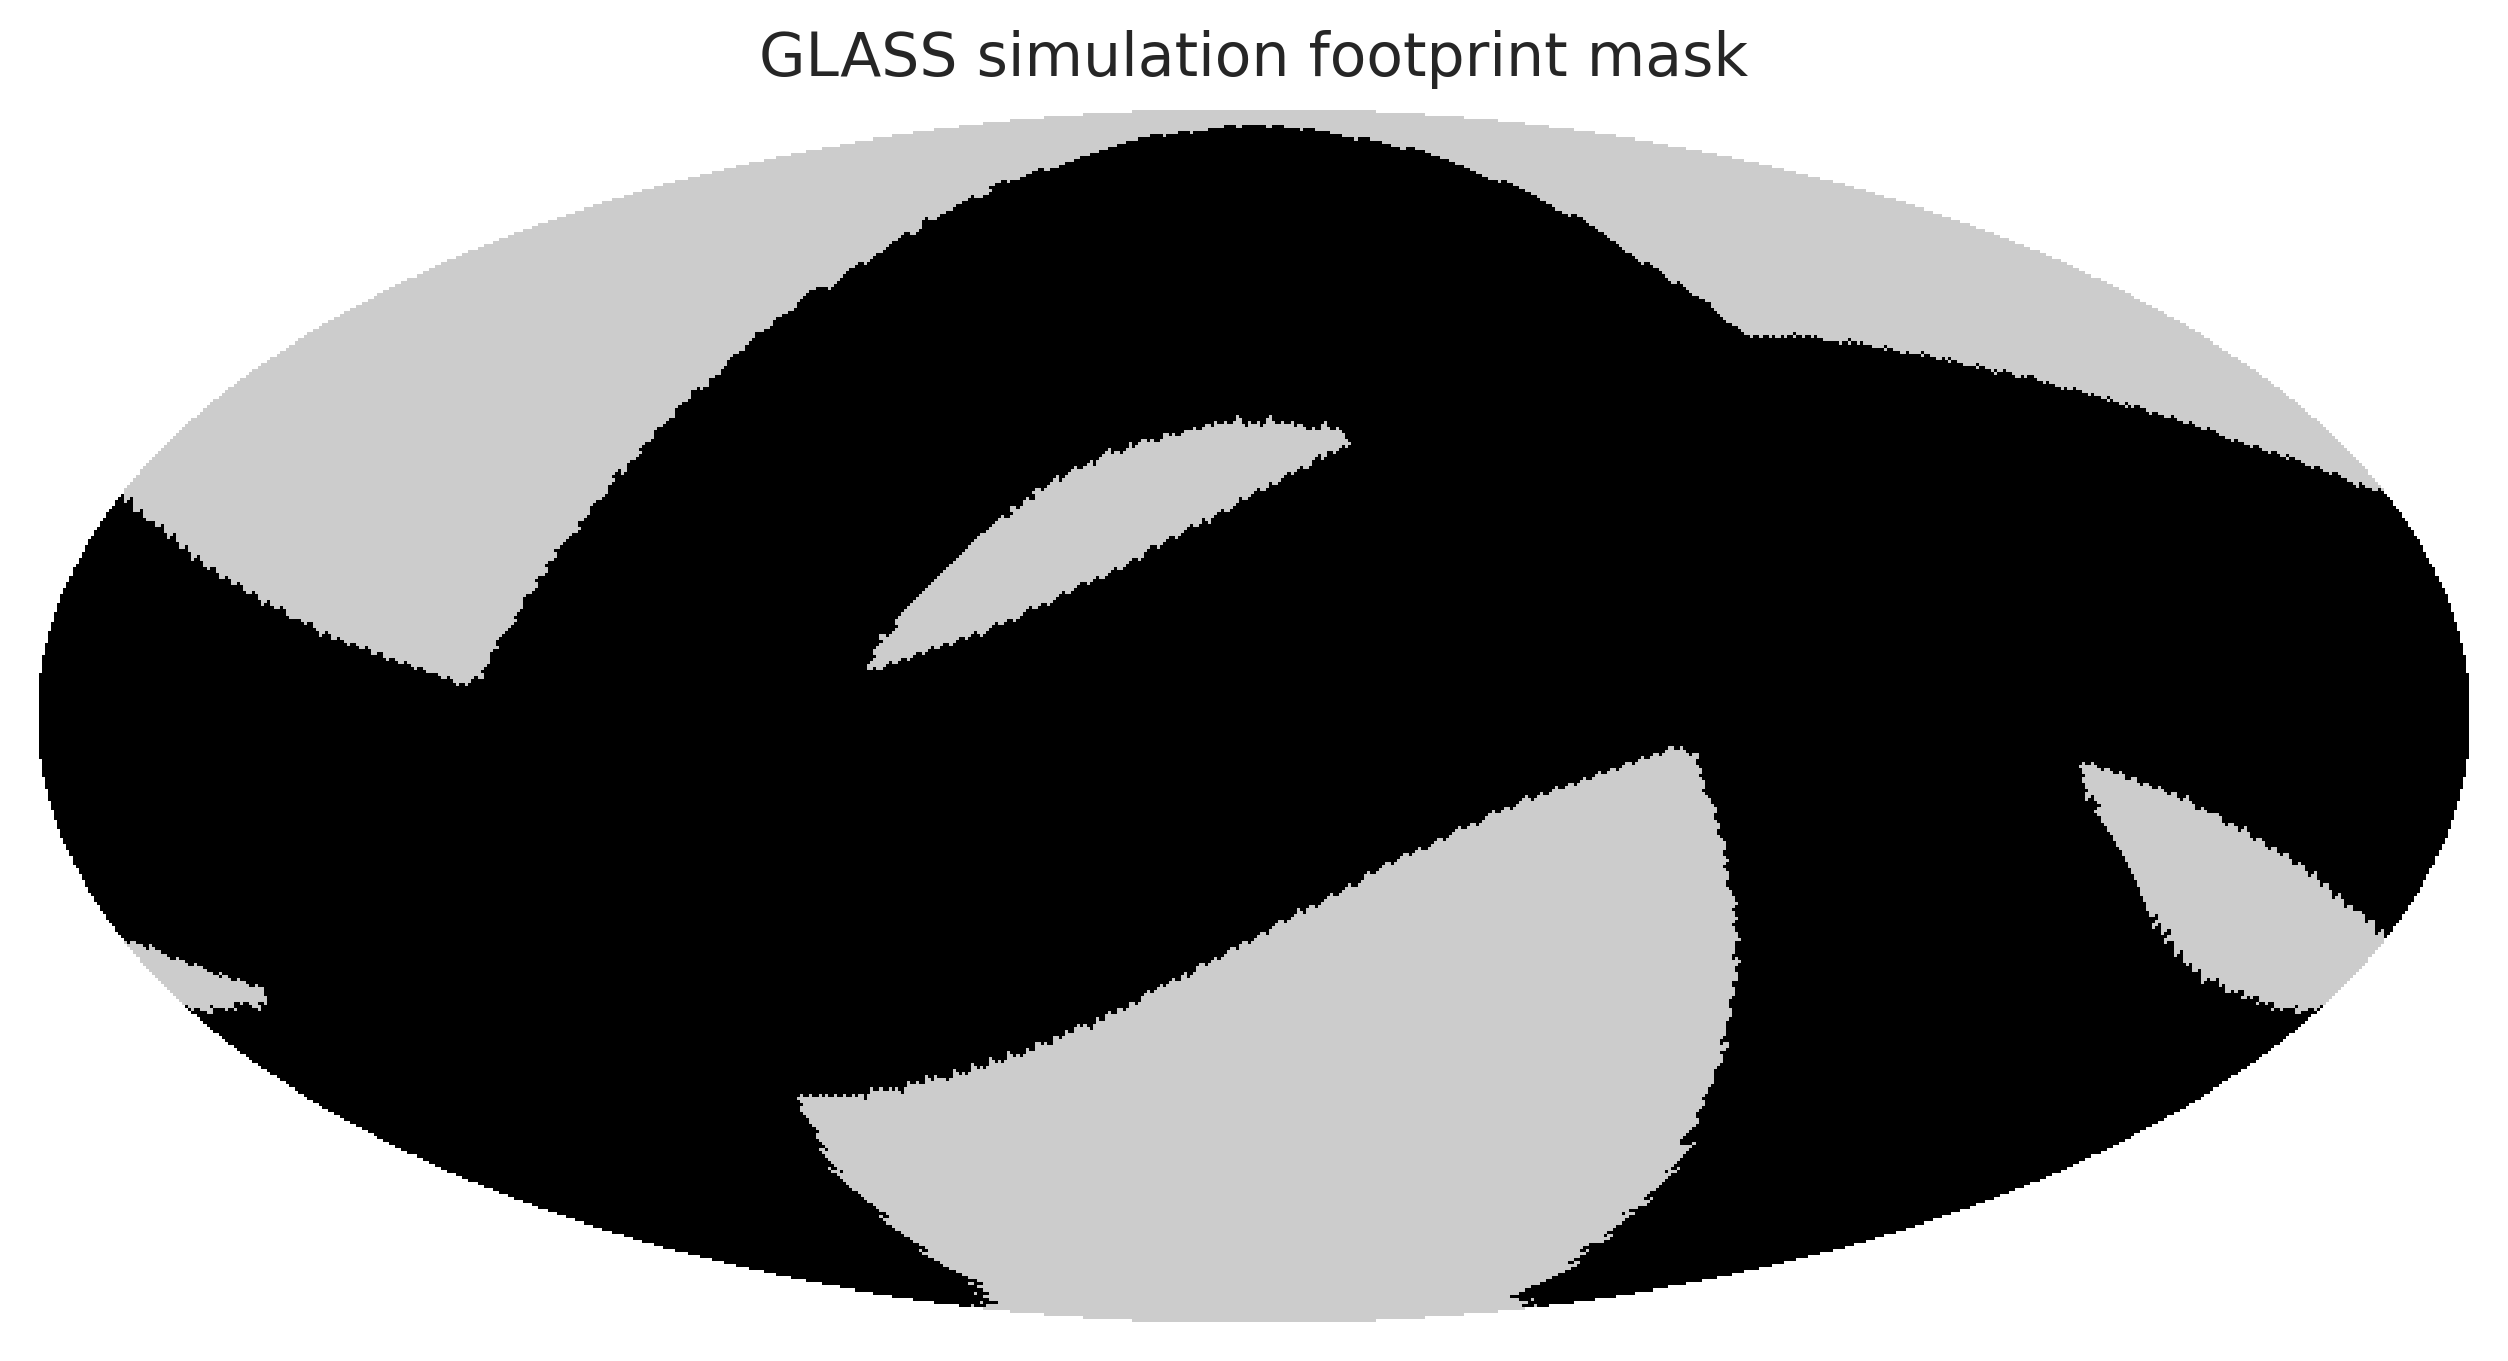

In [7]:
plt.rcParams['text.usetex'] = False
hp.mollview(mask, cmap='nipy_spectral', cbar=False, title='GLASS simulation footprint mask')
plt.show()


## Compute and save the fiducial power spectrum

As before, we need a fiducial theory power spectrum for the QML estimator. Here, the redshift
distribution is the custom Smail-type $n(z)$ actually used to generate the GLASS catalogue,
loaded from `data/nz_glass_custom.npz` - rather than an assumed Gaussian or the real TR1 $n(z)$.
The fiducial cosmology matches the one used to generate the GLASS catalogue (see
`examples/glass_fullsky_simulation.ipynb`).


In [8]:
# Fiducial cosmology, matching the one used to generate the GLASS catalogue
fiducial_cosmology = {'h': 0.7, 'Omega_c': 0.25, 'Omega_b': 0.05, 'sigma8': 0.75, 'n_s': 0.96,
                      'm_nu': 0.0, 'T_CMB': 2.7255, 'w0': -1.0, 'wa': 0.0}

# Custom Smail n(z), the one actually used to generate the GLASS catalogue
with np.load(f'{root_filepath}/data/nz_glass_custom.npz') as npz:
    redshift_range = npz['z']
    redshift_dist = npz['nz']

# Output file path
cl_file_path = f'{root_filepath}/data/theory_cl_vals/TheorySpectra_N{n_side}_glass.dat'

# Set up our PowerSpec class and compute the theory spectra
pow_spec = PowerSpec(n_side, fiducial_cosmology, redshift_range, redshift_dist, cl_file_path)

pow_spec.compute_power_spec()


Evaluating the theory Cl values using CCL


Saved the power spectrum to /home/vscode/WeakLensingQML/data/theory_cl_vals/TheorySpectra_N64_glass.dat


## Load the shear maps and shot-noise model

The `gamma1`/`gamma2` maps are already pixelised and saved by
`examples/glass_fullsky_simulation.ipynb`, so we just load them directly instead of re-building
them from the catalogue. The shot-noise model needs the intrinsic ellipticity dispersion and the
observed galaxy number density: `sigma_e` is taken directly from the known value used to generate
the catalogue, and the galaxy count comes straight from the FITS row count, so no scan over the
catalogue's data columns is needed.


In [ ]:
map_gamma1_path = f'{glass_filepath}/Map_glass_N{n_side}_gamma1.fits'
map_gamma2_path = f'{glass_filepath}/Map_glass_N{n_side}_gamma2.fits'

map_gamma1 = hp.read_map(map_gamma1_path)
map_gamma2 = hp.read_map(map_gamma2_path)

# The GLASS catalogue is a single fixed (potentially high-resolution) realisation, independent of
# the map n_side chosen above, so its filename is hardcoded rather than derived from n_side
catalog_filepath = f'{glass_filepath}/glass_catalog_N{n_side}.fits'
catalog = heracles.FitsCatalog(catalog_filepath)
catalog_bin = catalog[f'BIN == {tom_bin}']

# .size reads the row count straight from the FITS header (no data scan) and ignores the
# selection, but since the catalogue only has BIN == 1 that's exactly n_gal_bin here
n_gal_bin = catalog_bin.size


KeyboardInterrupt: 

We can now plot the GLASS simulation's cosmic shear map!


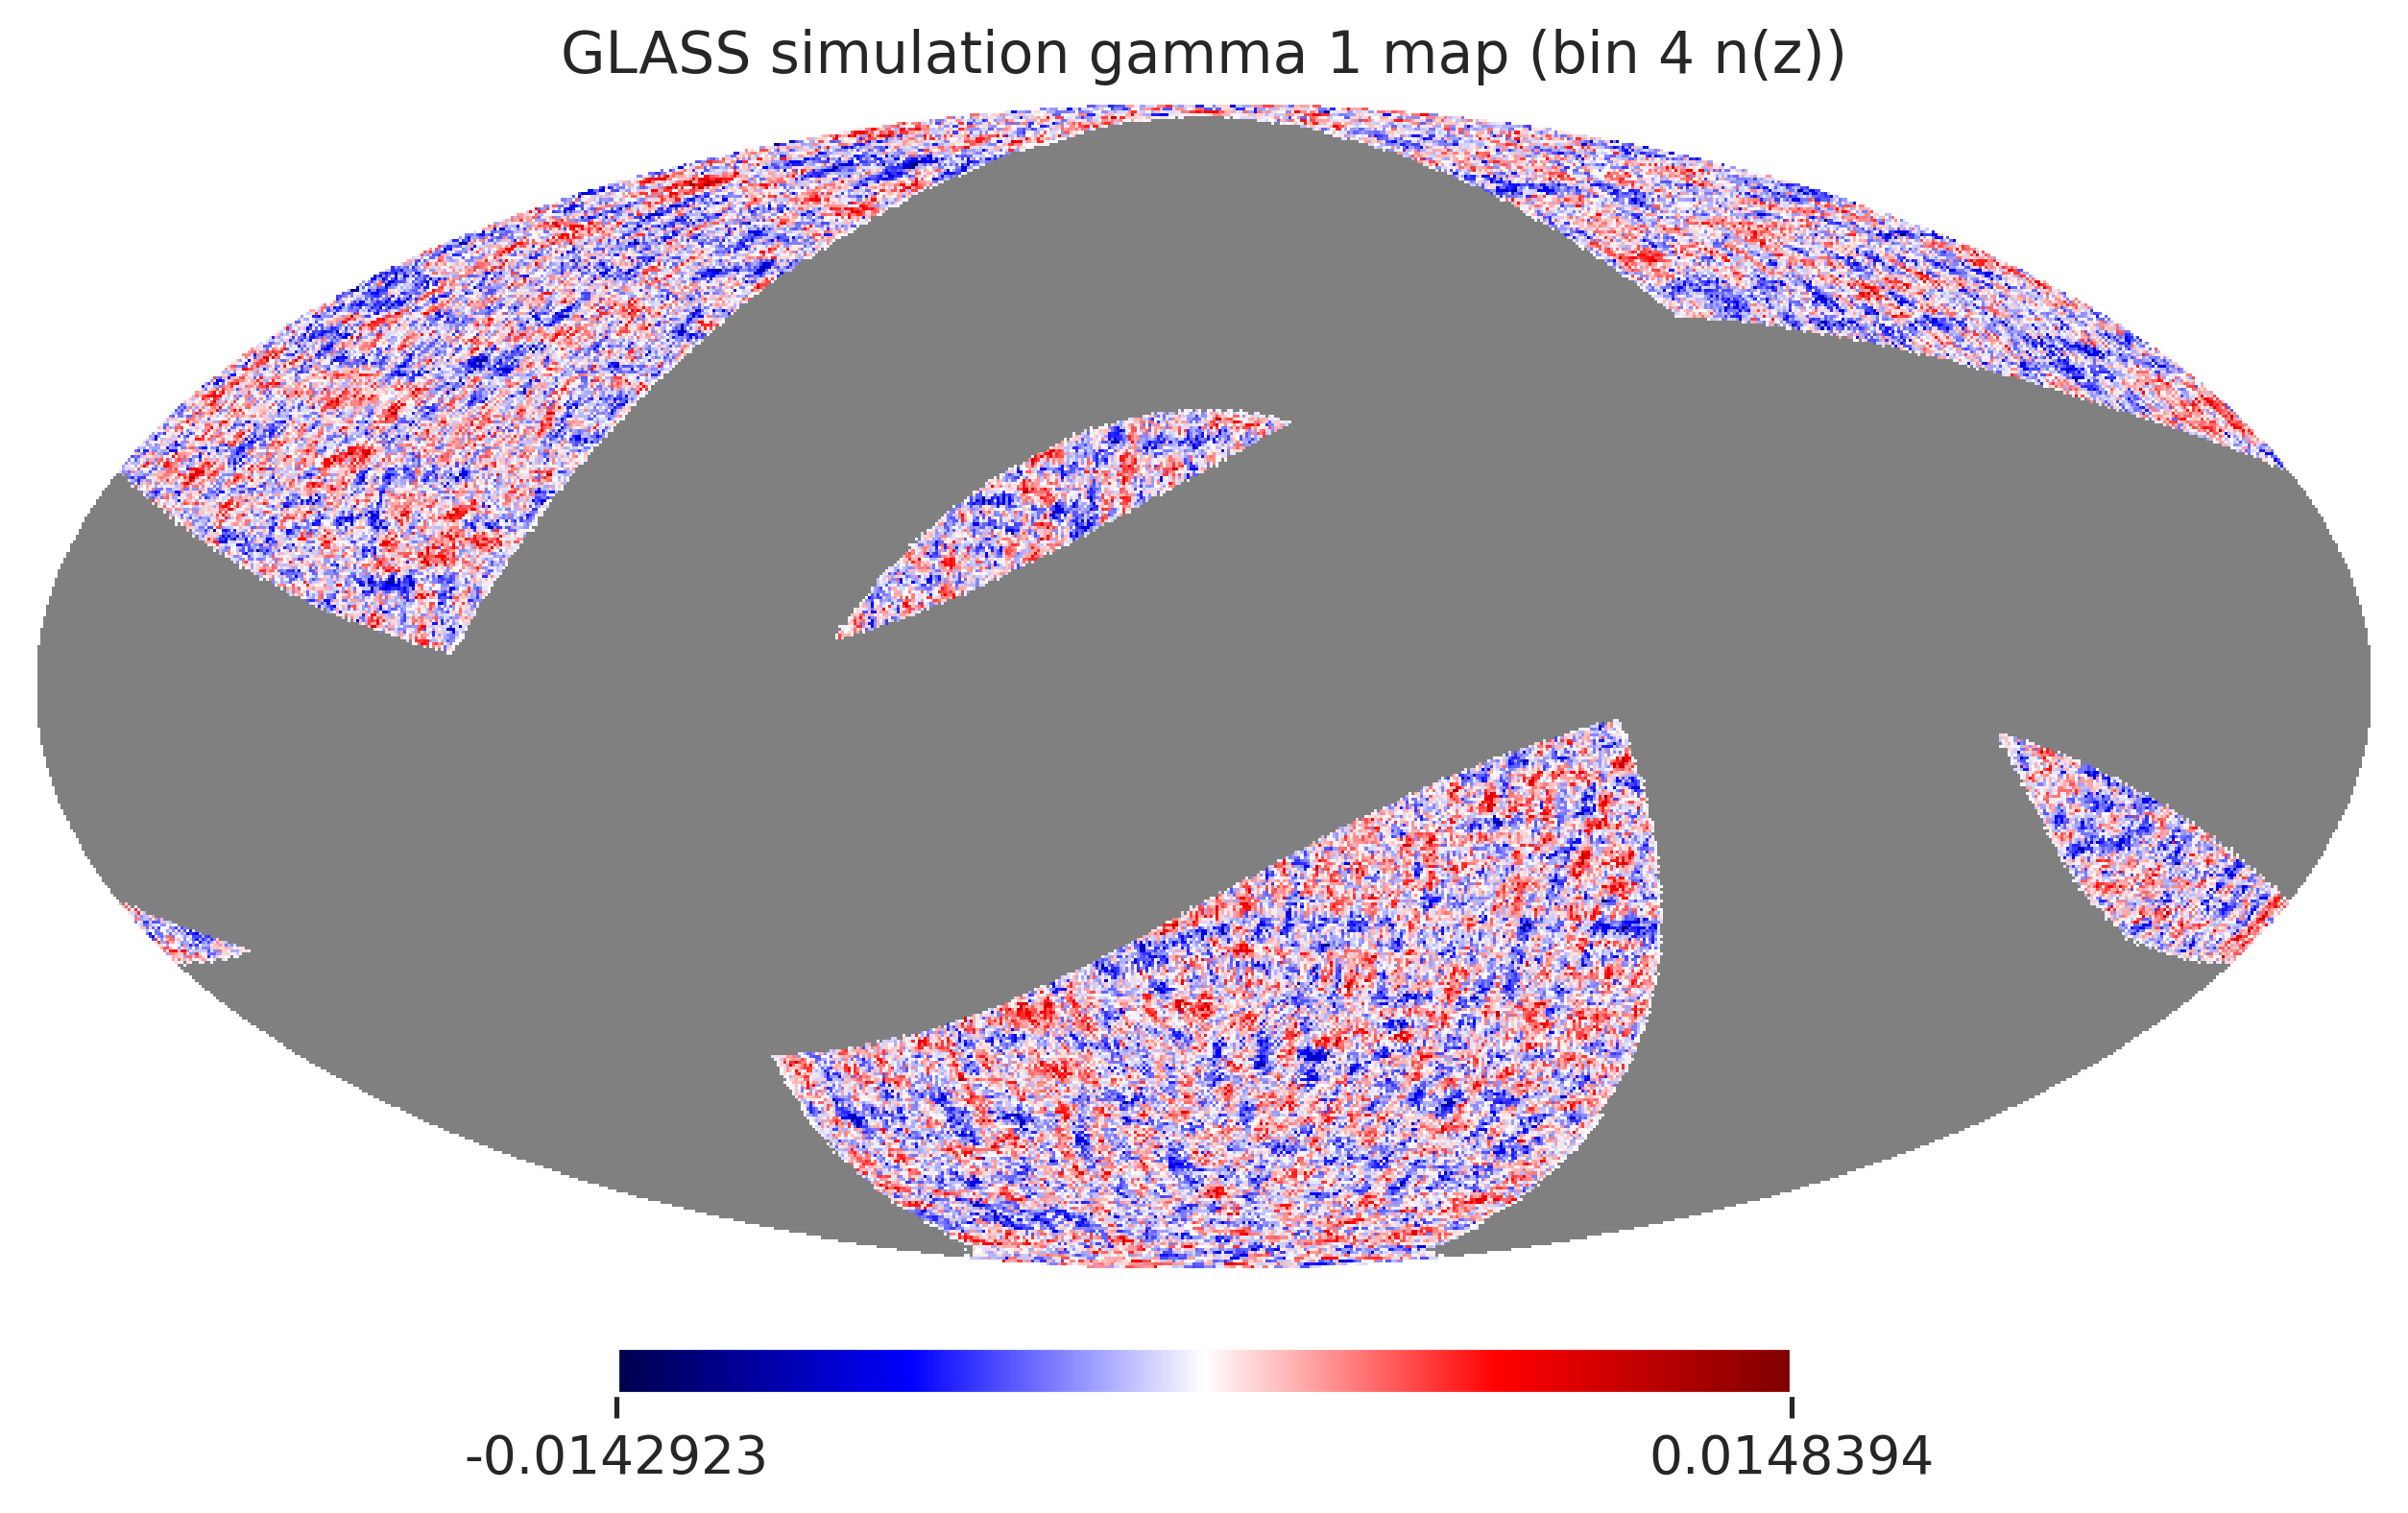

In [ ]:
plot_map_gamma1 = map_gamma1.copy()
plot_map_gamma1[plot_map_gamma1 == 0] = np.nan

plt.rcParams['text.usetex'] = False
hp.mollview(plot_map_gamma1, cmap='seismic', cbar=True, title='GLASS simulation gamma 1 map (custom n(z))')


As before, the intrinsic ellipticity of galaxies introduces a shot-noise term to the cosmic shear
power spectrum. Here, the intrinsic ellipticity dispersion $\sigma_{\epsilon}$ is the exact value
used to generate the GLASS catalogue (rather than an assumed literature value), and the observed
galaxy number density $\bar{n}$ is measured directly from the catalogue's row count and the
footprint.


In [ ]:
# sigma_e is the exact per-component intrinsic ellipticity dispersion used to generate the
# catalogue (see examples/glass_fullsky_simulation.ipynb); the shear added on top only shifts
# this by a negligible amount, so we use it directly instead of re-measuring it from the catalogue
intrinsic_gal_ellip = 0.3

# Observed galaxy number density within the survey footprint (gals / arcmin^2)
area_per_pix = 148_510_661 / n_pix
footprint_area = mask.sum() * area_per_pix
avg_gal_den = n_gal_bin / footprint_area

# Using the noise parameters, compute the theory noise Cl value
cl_noise = intrinsic_gal_ellip ** 2 / (avg_gal_den / (constants.arcminute ** 2))

# Then compute the expected number of galaxies per pixel
num_gal_per_pix = avg_gal_den * area_per_pix

# Compute the noise st. dev. and its associated variance
noise_std = intrinsic_gal_ellip / np.sqrt(num_gal_per_pix)
noise_var = noise_std ** 2

How the noise level compares to the signal here depends on the custom Smail `n(z)` and the
`sigma_e = 0.3`/density used to generate the GLASS catalogue, both of which differ from the base
notebook's assumed values ($\sigma_{\epsilon} = 0.21$, $3$ gals/arcmin$^2$). The cell below prints
these numbers directly.


In [ ]:
mean_z = np.trapezoid(redshift_range * redshift_dist, redshift_range) / np.trapezoid(redshift_dist, redshift_range)

base_cl_noise = 0.21 ** 2 / (3 / constants.arcminute ** 2)

print(f'GLASS custom n(z): mean z = {mean_z:.3f}')
print(f'n_gal_bin = {n_gal_bin:,}, avg_gal_den = {avg_gal_den:.3f} gals/arcmin^2, sigma_eps = {intrinsic_gal_ellip:.3f}')
print(f'cl_noise (this notebook) = {cl_noise:.3e}')
print(f'cl_noise (base example: sigma_eps=0.21, n=3/arcmin^2) = {base_cl_noise:.3e}')
print(f'noise ratio (this / base) = {cl_noise / base_cl_noise:.2f}x')


bin 4 n(z): mean z = 1.164
n_gal_bin = 868,069,844, avg_gal_den = 19.568 gals/arcmin^2, sigma_eps = 0.300
cl_noise (this notebook) = 3.883e-10
cl_noise (base example: sigma_eps=0.21, n=3/arcmin^2) = 1.244e-09
noise ratio (this / base) = 0.31x


## Quickly plot the power spectra

Now just plot the saved power spectra

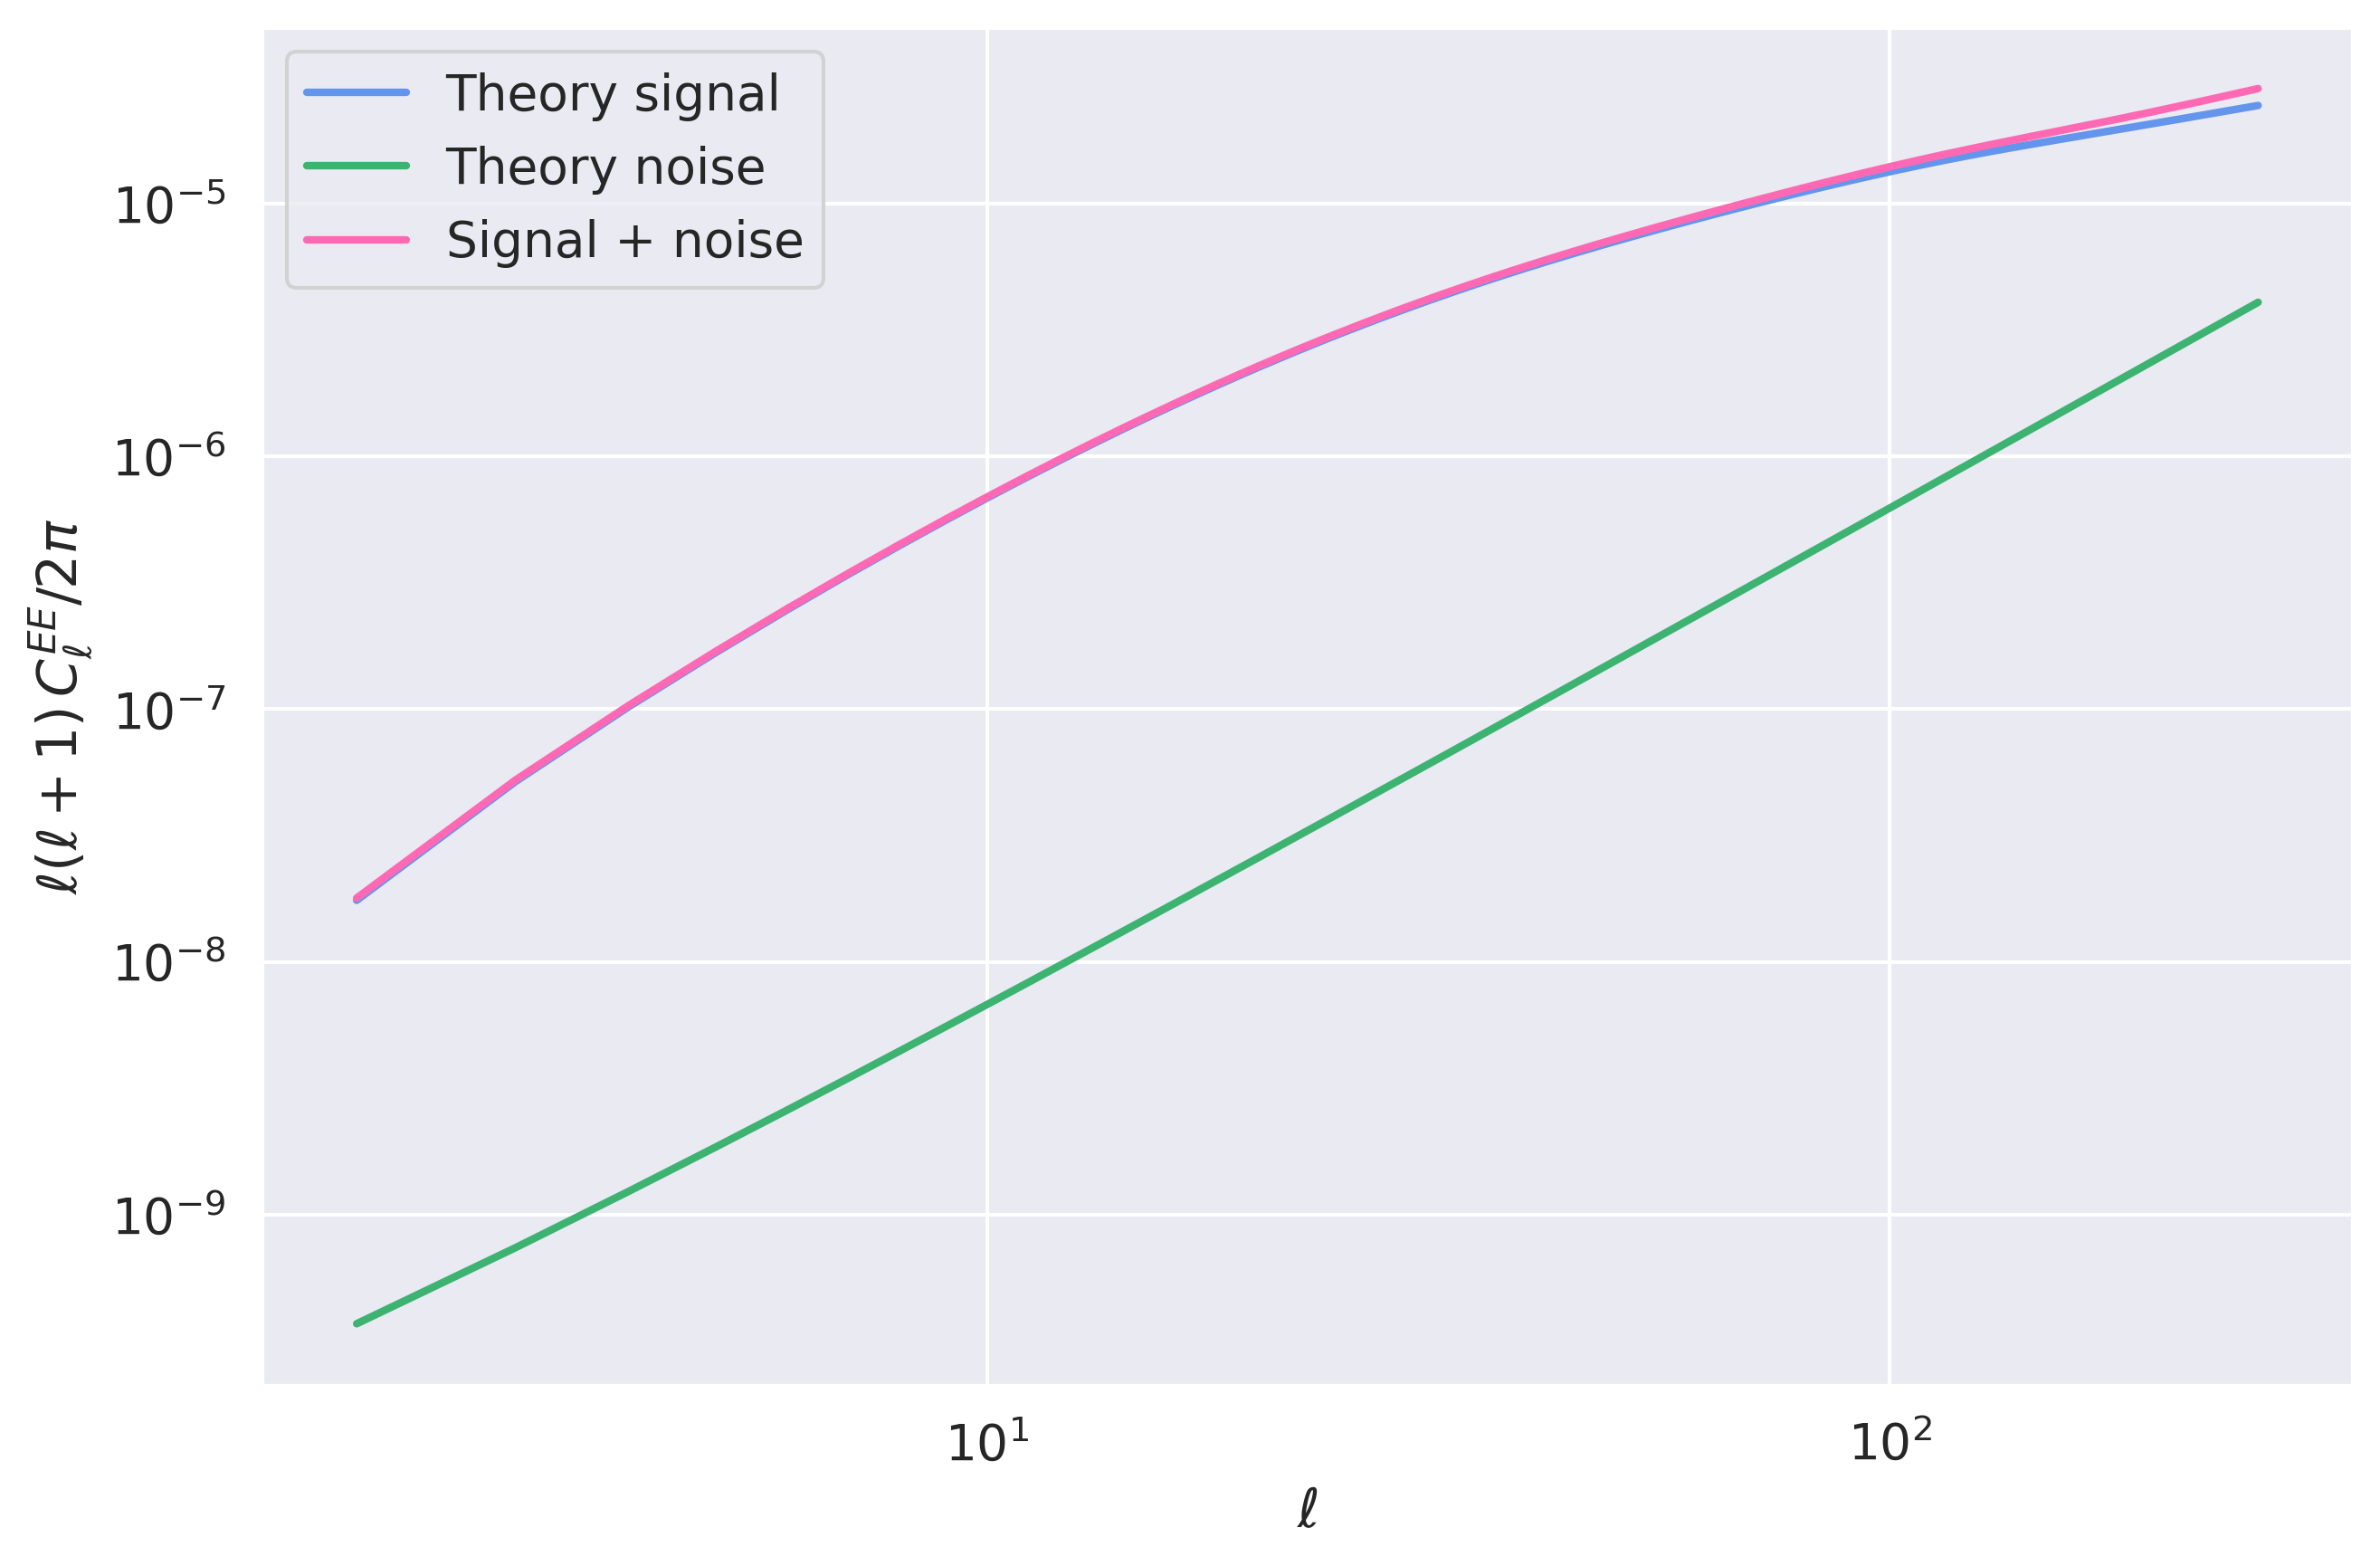

In [17]:
fix, ax = plt.subplots(figsize=(9, 6))

ax.loglog(ells, ells * (ells + 1) * pow_spec.cl_EE[2: l_max + 1] / (2 * np.pi), lw=2, c='cornflowerblue', label='Theory signal')
ax.loglog(ells, ells * (ells + 1) * cl_noise / (2 * np.pi), lw=2, c='mediumseagreen', label='Theory noise')
ax.loglog(ells, ells * (ells + 1) * (pow_spec.cl_EE[2: l_max + 1] + cl_noise) / (2 * np.pi), lw=2, c='hotpink', label='Signal + noise')

ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$\ell (\ell + 1) \, C_{\ell}^{EE} / 2 \pi$')

ax.legend()

plt.tight_layout()
plt.show()

## Load in the C++ library

We now need to load in the C++ library which contains the core QML algorithm for both estimating the covariance matrix and using that to estimate the power spectrum of our masked map.

The `num_maps` parameter determines how many maps we should average over when computing the estimate for the Fisher
matrix. The more maps the more accurate the final estimation will be, though with fewer maps the results will be unbiased. Please check our reference paper for a detailed discussion of this topic.

In [ ]:
num_maps = 10

In [ ]:
# First, generate the "constants.h" file that is necessary for the C++ code to compile (and thus run)
generate_constants_h(n_side, mask, noise_var, num_maps, root_filepath+'/cpp/detail/constants.h')

Now ensure that the C++ library has been compiled using the constants.h file that's been generated above.

**Note:** the mask used here differs from the one in the base example notebook, so `n_pix_mask`
will be different - if you already built the library for that notebook, you need to rebuild it
against this new `constants.h` before continuing.

To do so, go to the `cpp` directory and run the following commands
```
mkdir build
cd build/
cmake ..
make all
```

This should have built the shared library producing a `libQMLShearLib.so` file and a `QMLShearExe` executable file.

With the shared library compiled, we can load it into this Python script. First, we need to provide the file path for the shared library.

In [ ]:
import os

lib_path = f'{root_filepath}/cpp/build-release/libQMLShearLib.so'

if not os.path.exists(lib_path):
    raise FileNotFoundError(f'Expected shared library at {lib_path}. Build it first with: cmake -S cpp -B cpp/build && cmake --build cpp/build')

Now load in the library

In [ ]:
cpp_lib = CppLib(lib_path, mask_filepath, cl_file_path)

## Compute Fisher matrix

With our C++ library loaded, we can now compute and save the estimated Fisher matrix for our QML estimator for our mask and power spectrum

In [ ]:
fisher_matrix_out = f'{root_filepath}/data/Fisher_matrix_N{n_side}_glass.dat'


Do note that for map resolutions greater than `N_side` of about 64, the computation of the Fisher matrix can take a seriously long time!

For example, a run at `N_side = 64` using 16 cores took about 45 minutes, so be prepared for some long run-times!

In [ ]:
start_time = time.time()

cpp_lib.compute_fisher_matrix(fisher_matrix_out)

print(f'Computation took {(time.time() - start_time):,.1f} seconds')

Starting main now...
Computing fiducial y_ells now
Going through ell modes now
EB_idx: 0
ell: 3 9 10 2 6 7 8 4 11 5 

Once the Fisher matrix has been computed by the C++ code, we can load it in and perform analysis on it

In [21]:
fisher_matrix_QML = np.loadtxt(fisher_matrix_out)

# Delete any modes that corresponds to EB spectra as we can't measure that using our method
fisher_matrix_QML = np.delete(fisher_matrix_QML, np.s_[n_ell_full: 2 * n_ell_full], axis=0)
fisher_matrix_QML = np.delete(fisher_matrix_QML, np.s_[n_ell_full: 2 * n_ell_full], axis=1)

# Explicitly symeterise the Fisher matrix
fisher_matrix_QML = (fisher_matrix_QML.copy() + fisher_matrix_QML.copy().T) / 2

# Invert the Fisher matrix
inv_fisher_QML = np.linalg.inv(fisher_matrix_QML)

# Extract the EE-EE & BB-BB compoenets of the inverse Fisher matrix (the Cl covariance matrix)
cov_EE_EE_QML = inv_fisher_QML[0: n_ell, 0: n_ell]
cov_BB_BB_QML = inv_fisher_QML[n_ell_full: n_ell_full + n_ell, n_ell_full: n_ell_full + n_ell]

## Compute Pseudo-Cl covariance matrix

We now wish to compute the Pseudo-Cl estimate for the covariance matrix to compare to our QML result. Here, we use the `NaMaster` code to compute the PCl values.

In [22]:
# Create a NaMaster field for our given mask
field_mask = nmt.NmtField(mask, None, spin=2)

# Create a bins object with one ell mode per bin
bins = nmt.NmtBin.from_nside_linear(n_side, 1)

# Create a regular workspace object
wsp = nmt.NmtWorkspace()
wsp.compute_coupling_matrix(field_mask, field_mask, bins)

# Create a covariance workspace object and compute the coupling coefficients from the fields
covar_wsp = nmt.NmtCovarianceWorkspace.from_fields(field_mask, field_mask, field_mask, field_mask)

# Shortcuts for the power spectrum
cl_EE = pow_spec.cl_EE
cl_EB = np.zeros_like(cl_EE)
cl_BB = np.zeros_like(cl_EE)

# Compute the Gaussian covariance estimation
covar_22_22 = nmt.gaussian_covariance(covar_wsp, 2, 2, 2, 2,
                                [cl_EE + cl_noise, cl_EB, cl_EB, cl_BB + cl_noise],
                                [cl_EE + cl_noise, cl_EB, cl_EB, cl_BB + cl_noise],
                                [cl_EE + cl_noise, cl_EB, cl_EB, cl_BB + cl_noise],
                                [cl_EE + cl_noise, cl_EB, cl_EB, cl_BB + cl_noise],
                                wsp, wb=wsp).reshape([n_ell_full, 4, n_ell_full, 4])

# Extract the specific EE-EE & BB-BB components of the full covariance matrix
cov_EE_EE_PCl = covar_22_22[:, 0, :, 0][0: n_ell, 0: n_ell]
cov_BB_BB_PCl = covar_22_22[:, 3, :, 3][0: n_ell, 0: n_ell]

## Plot the ratio of the PCl to QML covariances

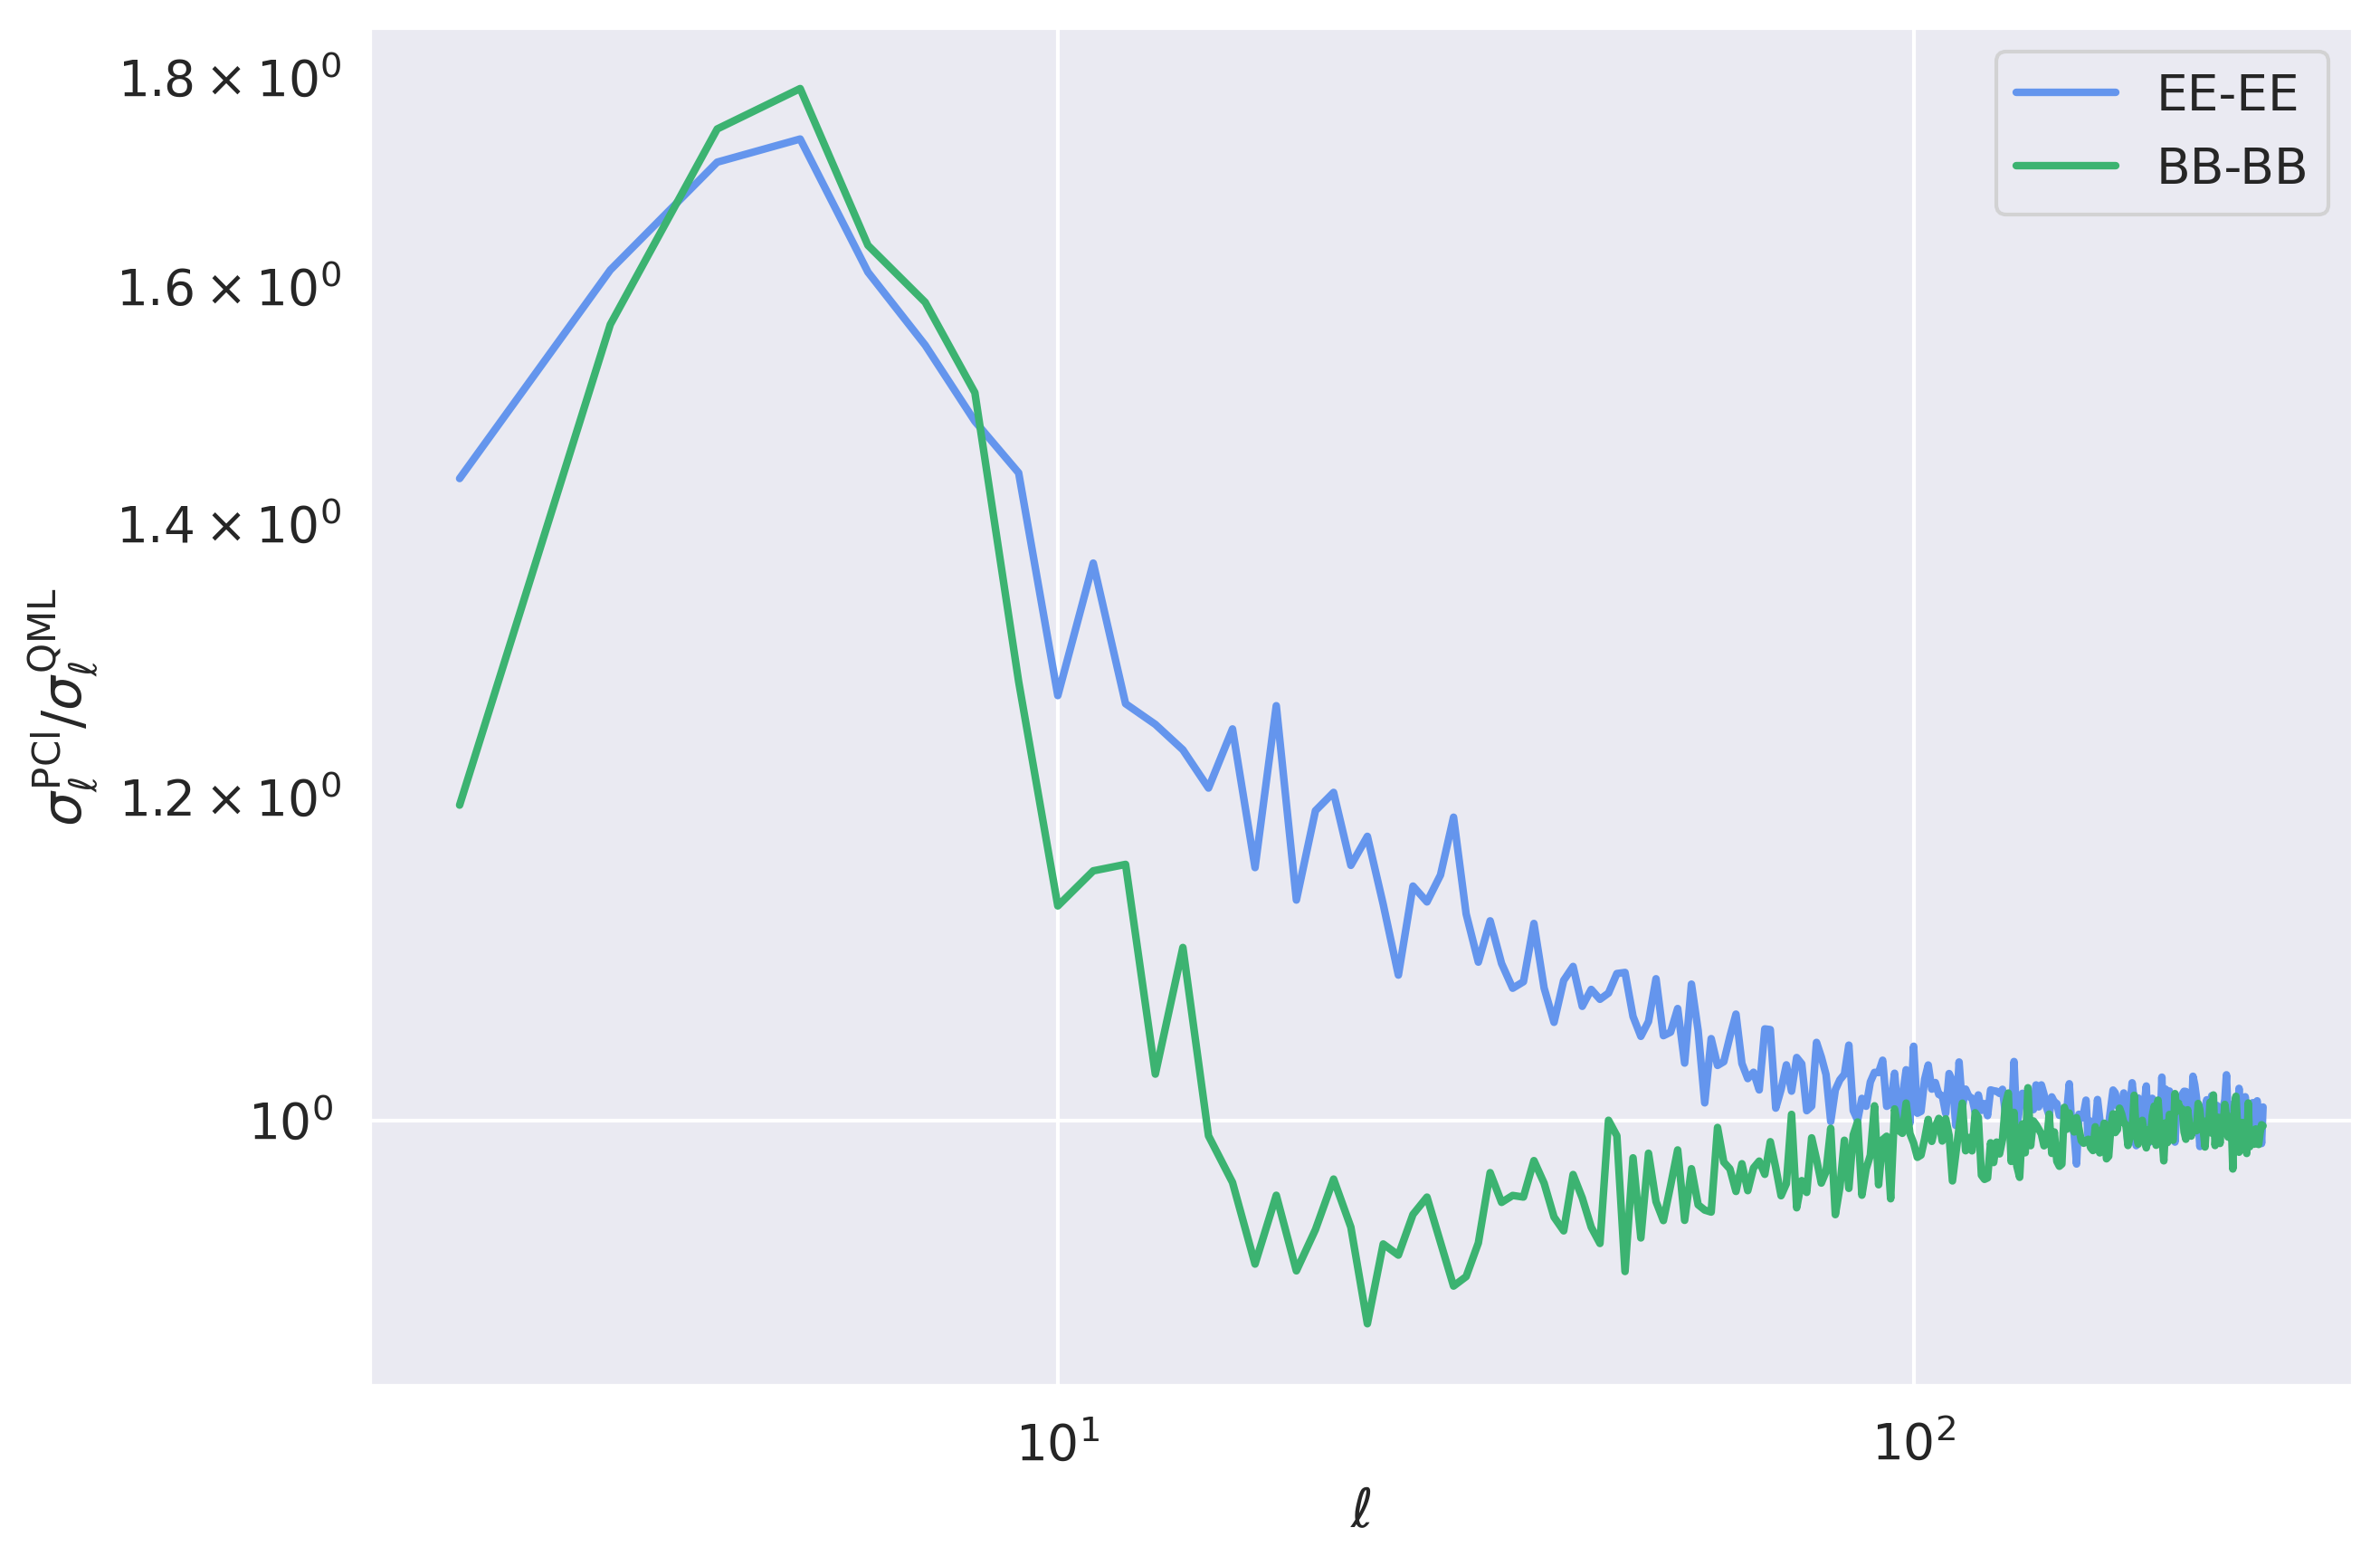

In [23]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.loglog(ells, np.sqrt(np.diag(cov_EE_EE_PCl / cov_EE_EE_QML)), c='cornflowerblue', lw=2, label='EE-EE')
ax.loglog(ells, np.sqrt(np.diag(cov_BB_BB_PCl / cov_BB_BB_QML)), c='mediumseagreen', lw=2, label='BB-BB')

ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$\sigma_{\ell}^{\mathrm{PCl}} / \sigma_{\ell}^{\mathrm{QML}}$')

ax.legend()
plt.tight_layout()
plt.show()

## Now use the Fisher matrix to estimate the power spectrum of the real bin-1 map

With the Fisher matrix estimated, we can now use it to produce a QML estimate of the power spectrum for the real bin-1 cosmic shear map built above.

In [ ]:
# Filepath to store the y_ell values in
y_ell_output = f'{root_filepath}/data/y_ell_out_N{n_side}_glass.dat'

# Execute the C++ code
cpp_lib.compute_power_spectrum(map_gamma1_path, map_gamma2_path, y_ell_output)


With the $y_{\ell}$ values computed, we can read them in and analyse them here

In [25]:
# Load the y_ell values
y_ell_QML = np.loadtxt(y_ell_output)

# Again, we have to delete any modes corresponding to EB spectra as we can't measure them
y_ell_QML = np.delete(y_ell_QML, np.s_[n_ell_full: 2 * n_ell_full], axis=0)

With our $y_{\ell}$ values and the inverse Fisher matrix, we can now compute estimates for the power spectrum coefficients $C_{\ell}$ for the QML estimator.

In [26]:
cl_QML = inv_fisher_QML @ y_ell_QML

# Extract specific components of the Cl values
cl_EE_QML = cl_QML[0: n_ell]
cl_BB_QML = cl_QML[n_ell_full: n_ell_full + n_ell]

Now compute the PCl estimation of the power spectrum using NaMaster

In [27]:
field_shear = nmt.NmtField(mask, [map_gamma1, map_gamma2])
cl_EE_PCl, cl_BB_PCl = nmt.compute_full_master(field_shear, field_shear, bins)[[0, 3], 0: n_ell]

With our estimates of the power spectrum from our two methods, we can plot their results along with the fiducial theory curve to see how well they match and compare with each other.

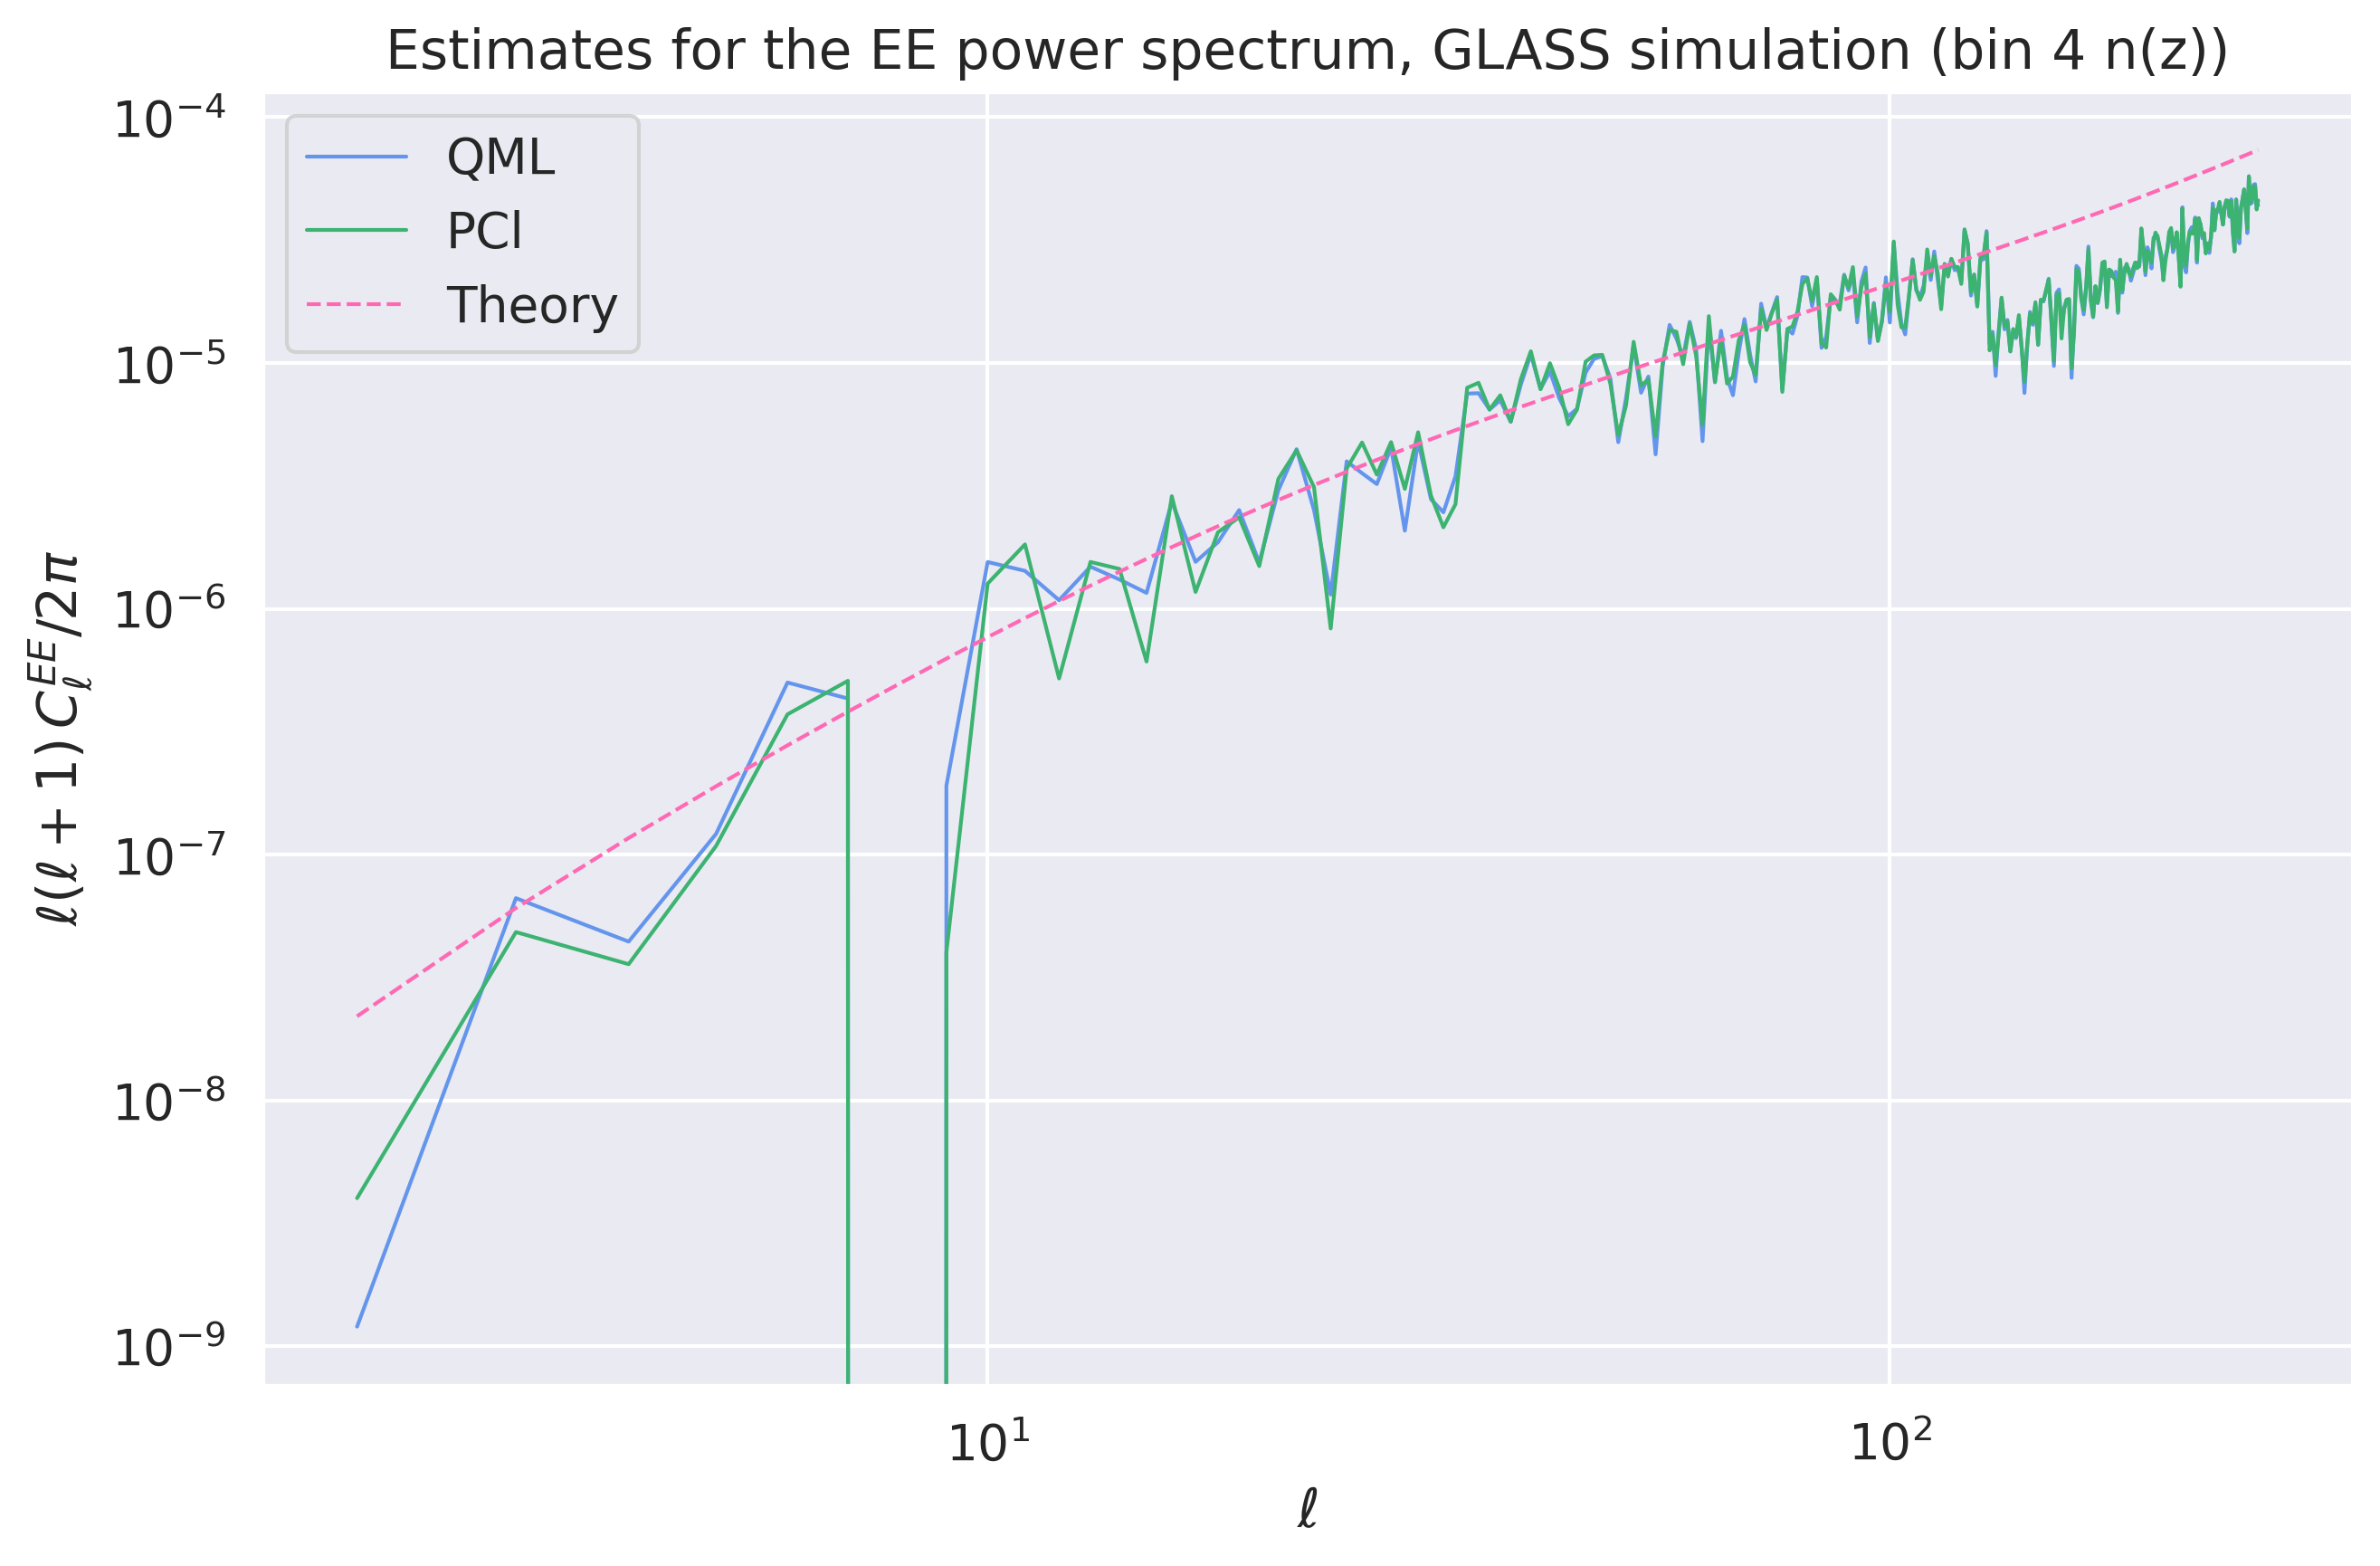

In [ ]:
fix, ax = plt.subplots(figsize=(9, 6))

ax.loglog(ells, ells * (ells + 1) * cl_EE_QML / (2 * np.pi), lw=1, c='cornflowerblue', label='QML')
ax.loglog(ells, ells * (ells + 1) * cl_EE_PCl / (2 * np.pi), lw=1, c='mediumseagreen', label='PCl')

ax.loglog(ells, ells * (ells + 1) * (pow_spec.cl_EE[2: l_max + 1] + cl_noise) / (2 * np.pi), lw=1, ls='--', c='hotpink', label='Theory')

ax.set_title('Estimates for the EE power spectrum, GLASS simulation (custom n(z))')
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$\ell (\ell + 1) \, C_{\ell}^{EE} / 2 \pi$')

ax.legend()

plt.tight_layout()
plt.show()


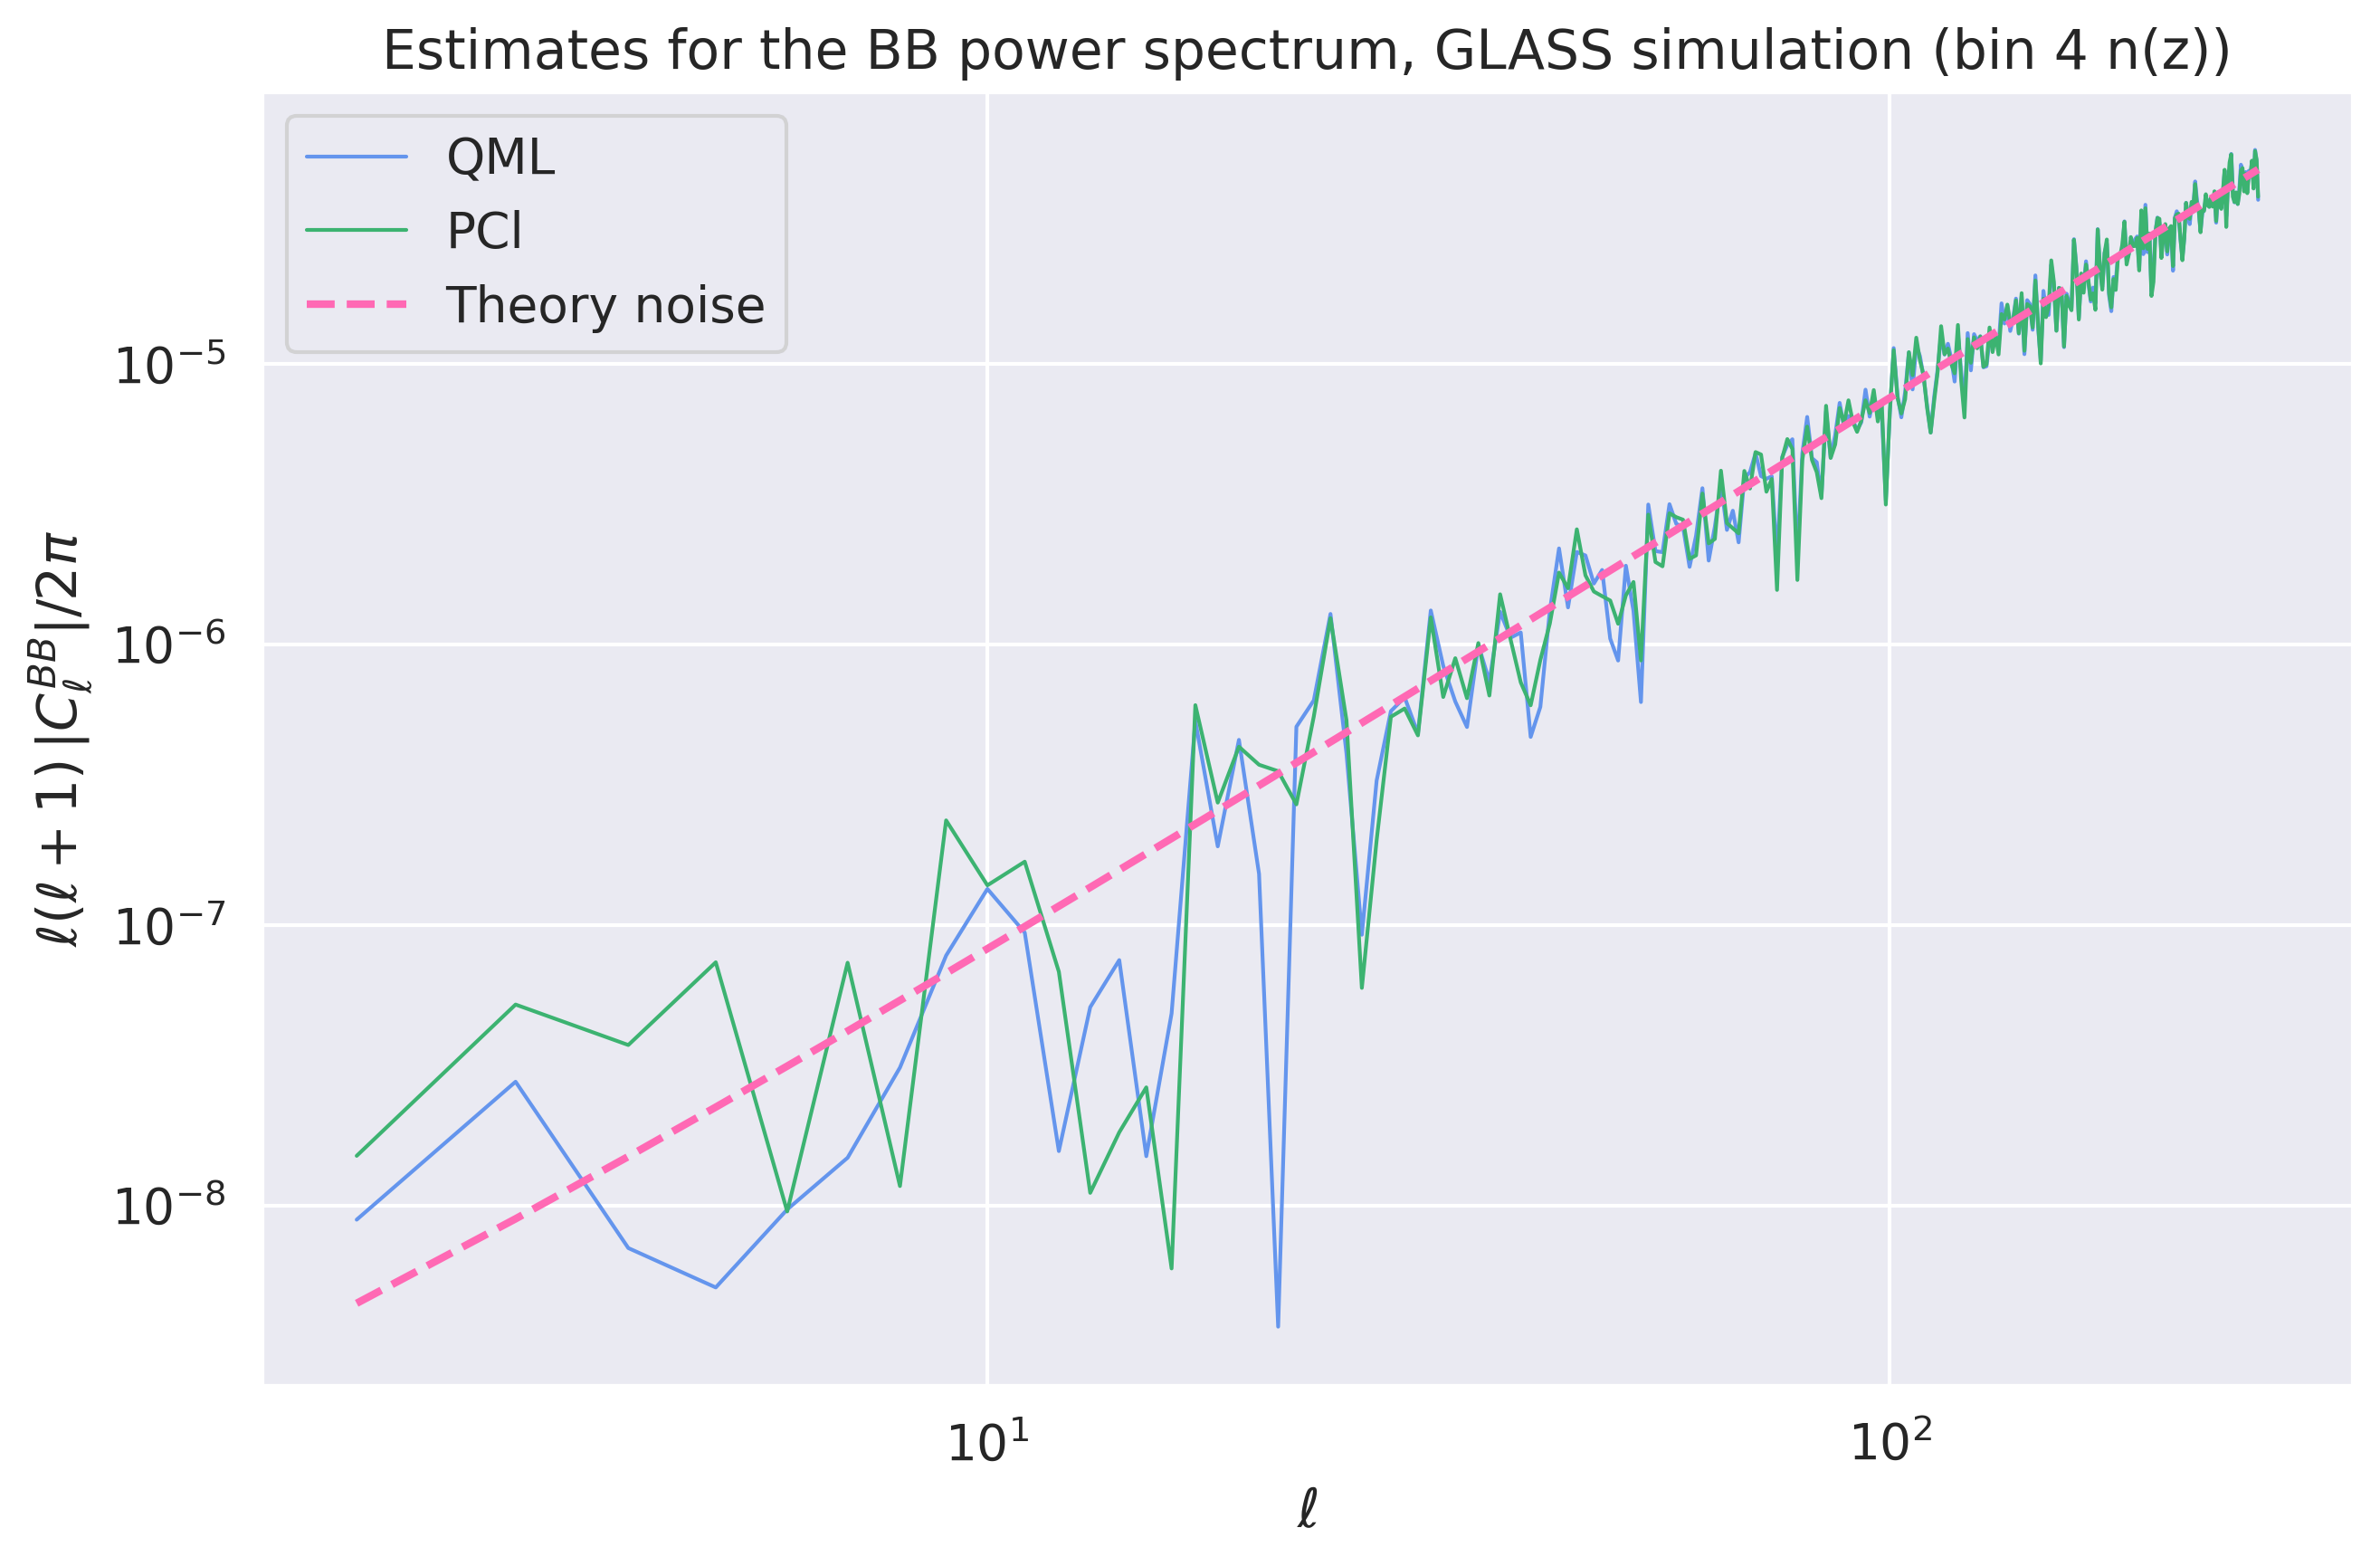

In [ ]:
fix, ax = plt.subplots(figsize=(9, 6))

ax.loglog(ells, ells * (ells + 1) * np.abs(cl_BB_QML) / (2 * np.pi), lw=1, c='cornflowerblue', label='QML')
ax.loglog(ells, ells * (ells + 1) * np.abs(cl_BB_PCl) / (2 * np.pi), lw=1, c='mediumseagreen', label='PCl')

ax.loglog(ells, ells * (ells + 1) * cl_noise / (2 * np.pi), lw=2, ls='--', c='hotpink', label='Theory noise')

ax.set_title('Estimates for the BB power spectrum, GLASS simulation (custom n(z))')
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$\ell (\ell + 1) \, |C_{\ell}^{BB}| / 2 \pi$')

ax.legend()

plt.tight_layout()
plt.show()


## Compare against heracles' own power spectrum estimator

As a third estimator, run heracles' own catalogue-to-Cl pipeline (`map_catalogs` + `transform` +
`angular_power_spectra`) directly on the same GLASS catalogue and mask used above. heracles
returns the raw, mode-coupled pseudo-Cl, so we build heracles' own mixing matrix from the mask's
power spectrum (`mixing_matrices` + `invert_mixing_matrix` + `apply_mixing_matrix`) to decouple
it, rather than borrowing NaMaster's mixing matrix - keeping the decoupling fully self-consistent
with heracles' own conventions. This tracks QML/PCl closely across the full `l` range, with just
some extra scatter/downward dips above `l ~ 60` (likely from heracles' internal HEALPix
pixel-window deconvolution amplifying noise near the map's resolution limit).


In [30]:
import heracles.healpy
import healpy.sphtfunc

# Work around a blocked SSL download of healpy's pixel-window file by pointing it at the
# local copy already fetched for examples/glass_fullsky_simulation.ipynb
healpy.sphtfunc.DATAURL = f'file://{root_filepath}/examples/'

mapper = heracles.healpy.HealpixMapper(n_side, l_max_full)
mapper2 = heracles.healpy.HealpixMapper(2*n_side, 2*l_max_full)
she_cat = catalog_bin
she_cat.visibility = mask.astype(float)

fieldsShe = {
    'SHE': heracles.Shears(mapper, 'RA', 'DEC', 'E1', 'E2', 'W', mask='WHT'),
    'WHT': heracles.Weights(mapper, 'RA', 'DEC', 'W'),
}

fieldsShe2 = {
    'SHE': heracles.Shears(mapper2, 'RA', 'DEC', 'E1', 'E2', 'W', mask='WHT'),
    'WHT': heracles.Weights(mapper2, 'RA', 'DEC', 'W'),
}

data_she = heracles.map_catalogs(fieldsShe, {tom_bin: she_cat}, parallel=True)
alms_she = heracles.transform(fieldsShe, data_she)
data_she2 = heracles.map_catalogs(fieldsShe2, {tom_bin: she_cat}, parallel=True)
alms_she2 = heracles.transform(fieldsShe2, data_she2)
# Raw (mode-coupled) pseudo-Cl for both the shear field and its mask/weight field - the latter
# is needed to build heracles' own mixing matrix below
cls_she_unbinned = heracles.angular_power_spectra(alms_she, include=[('SHE', 'SHE'), ('WHT', 'WHT')])
cls_she_unbinned2 = heracles.angular_power_spectra(alms_she2, include=[('SHE', 'SHE'), ('WHT', 'WHT')])
# Build heracles' own mixing matrix from the mask's power spectrum, then invert and apply it to
# decouple the raw pseudo-Cl - this keeps the decoupling fully self-consistent with heracles,
# rather than borrowing NaMaster's mixing matrix (`wsp`) as used for the PCl estimate above
mixing_mats = heracles.mixing_matrices(fieldsShe2, cls_she_unbinned2)
inv_mixing_mats = heracles.invert_mixing_matrix(mixing_mats)

she_she_key = ('SHE', 'SHE', tom_bin, tom_bin)
cls_she_decoupled = heracles.apply_mixing_matrix({she_she_key: cls_she_unbinned2[she_she_key]}, inv_mixing_mats)

cl_EE_heracles = np.array(cls_she_decoupled[she_she_key][0, 0])[2: l_max + 1]
cl_BB_heracles = np.array(cls_she_decoupled[she_she_key][1, 1])[2: l_max + 1]



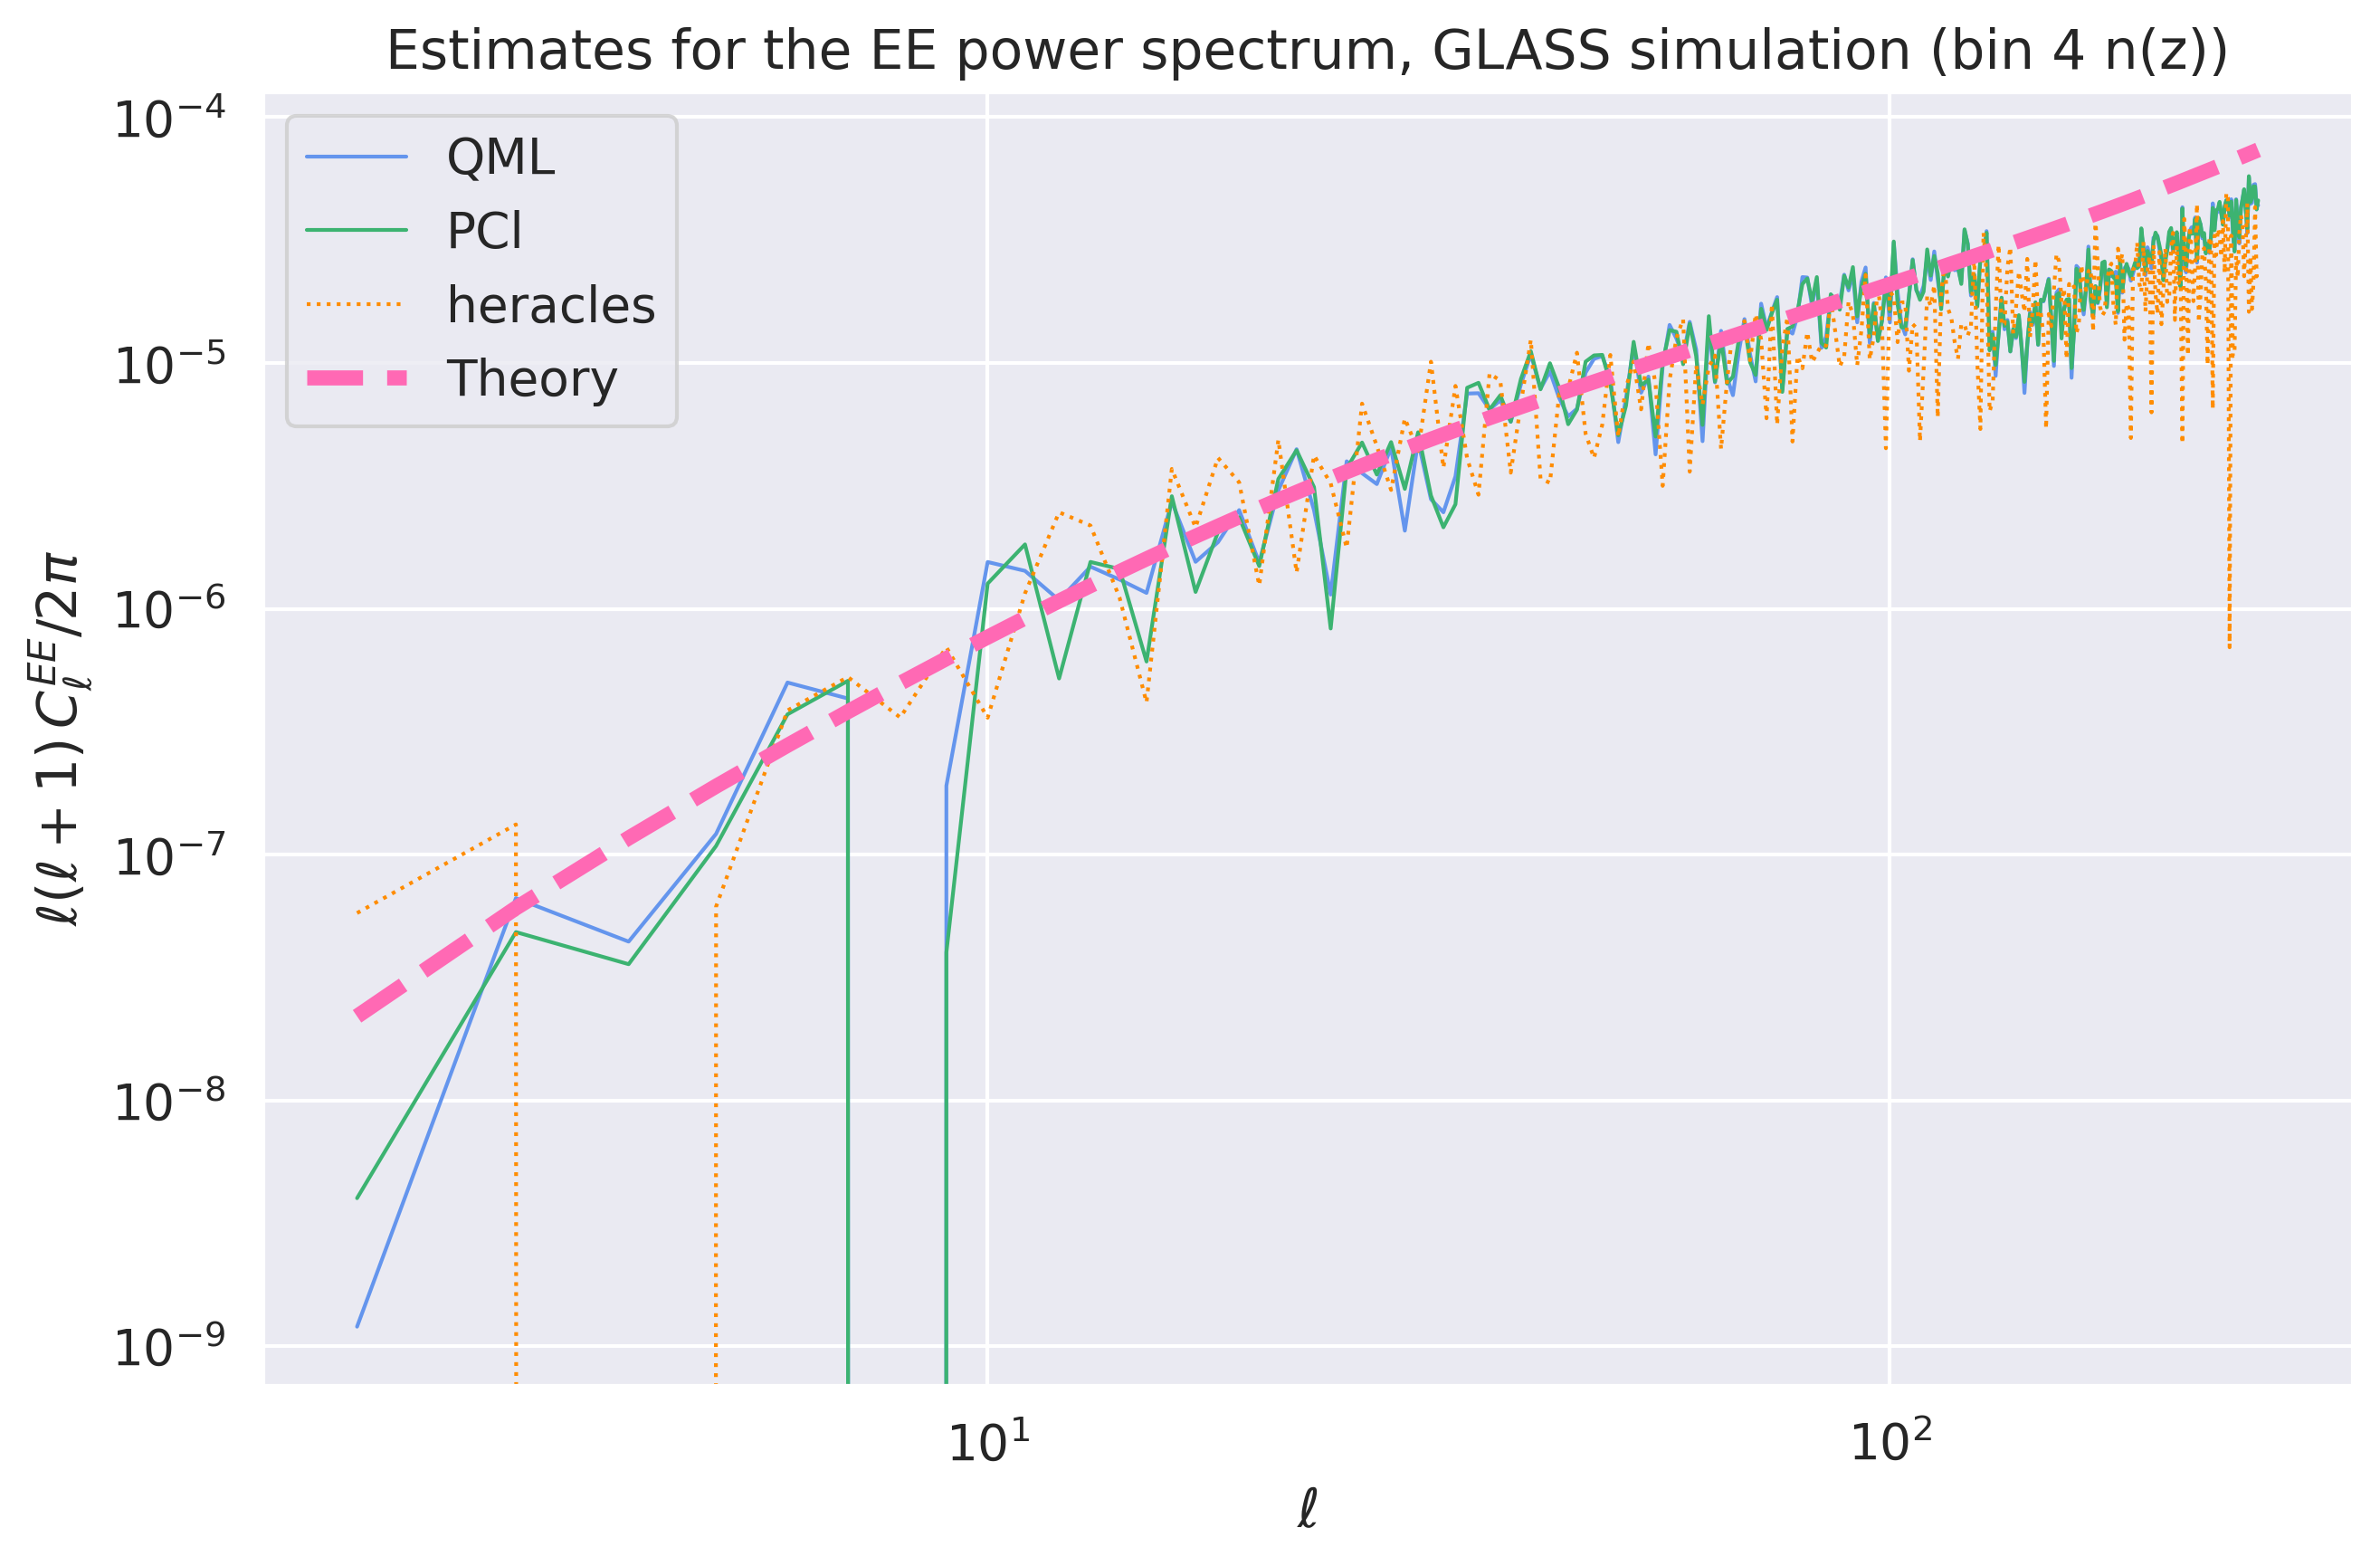

In [ ]:
fix, ax = plt.subplots(figsize=(9, 6))

ax.loglog(ells, ells * (ells + 1) * cl_EE_QML / (2 * np.pi), lw=1, c='cornflowerblue', label='QML')
ax.loglog(ells, ells * (ells + 1) * cl_EE_PCl / (2 * np.pi), lw=1, c='mediumseagreen', label='PCl')
ax.loglog(ells, ells * (ells + 1) * cl_EE_heracles / (2 * np.pi), lw=1, ls=':', c='darkorange', label='heracles')

ax.loglog(ells, ells * (ells + 1) * (pow_spec.cl_EE[2: l_max + 1] + cl_noise) / (2 * np.pi), lw=4, ls='--', c='hotpink', label='Theory')

ax.set_title('Estimates for the EE power spectrum, GLASS simulation (custom n(z))')
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$\ell (\ell + 1) \, C_{\ell}^{EE} / 2 \pi$')

ax.legend()

plt.tight_layout()
plt.show()


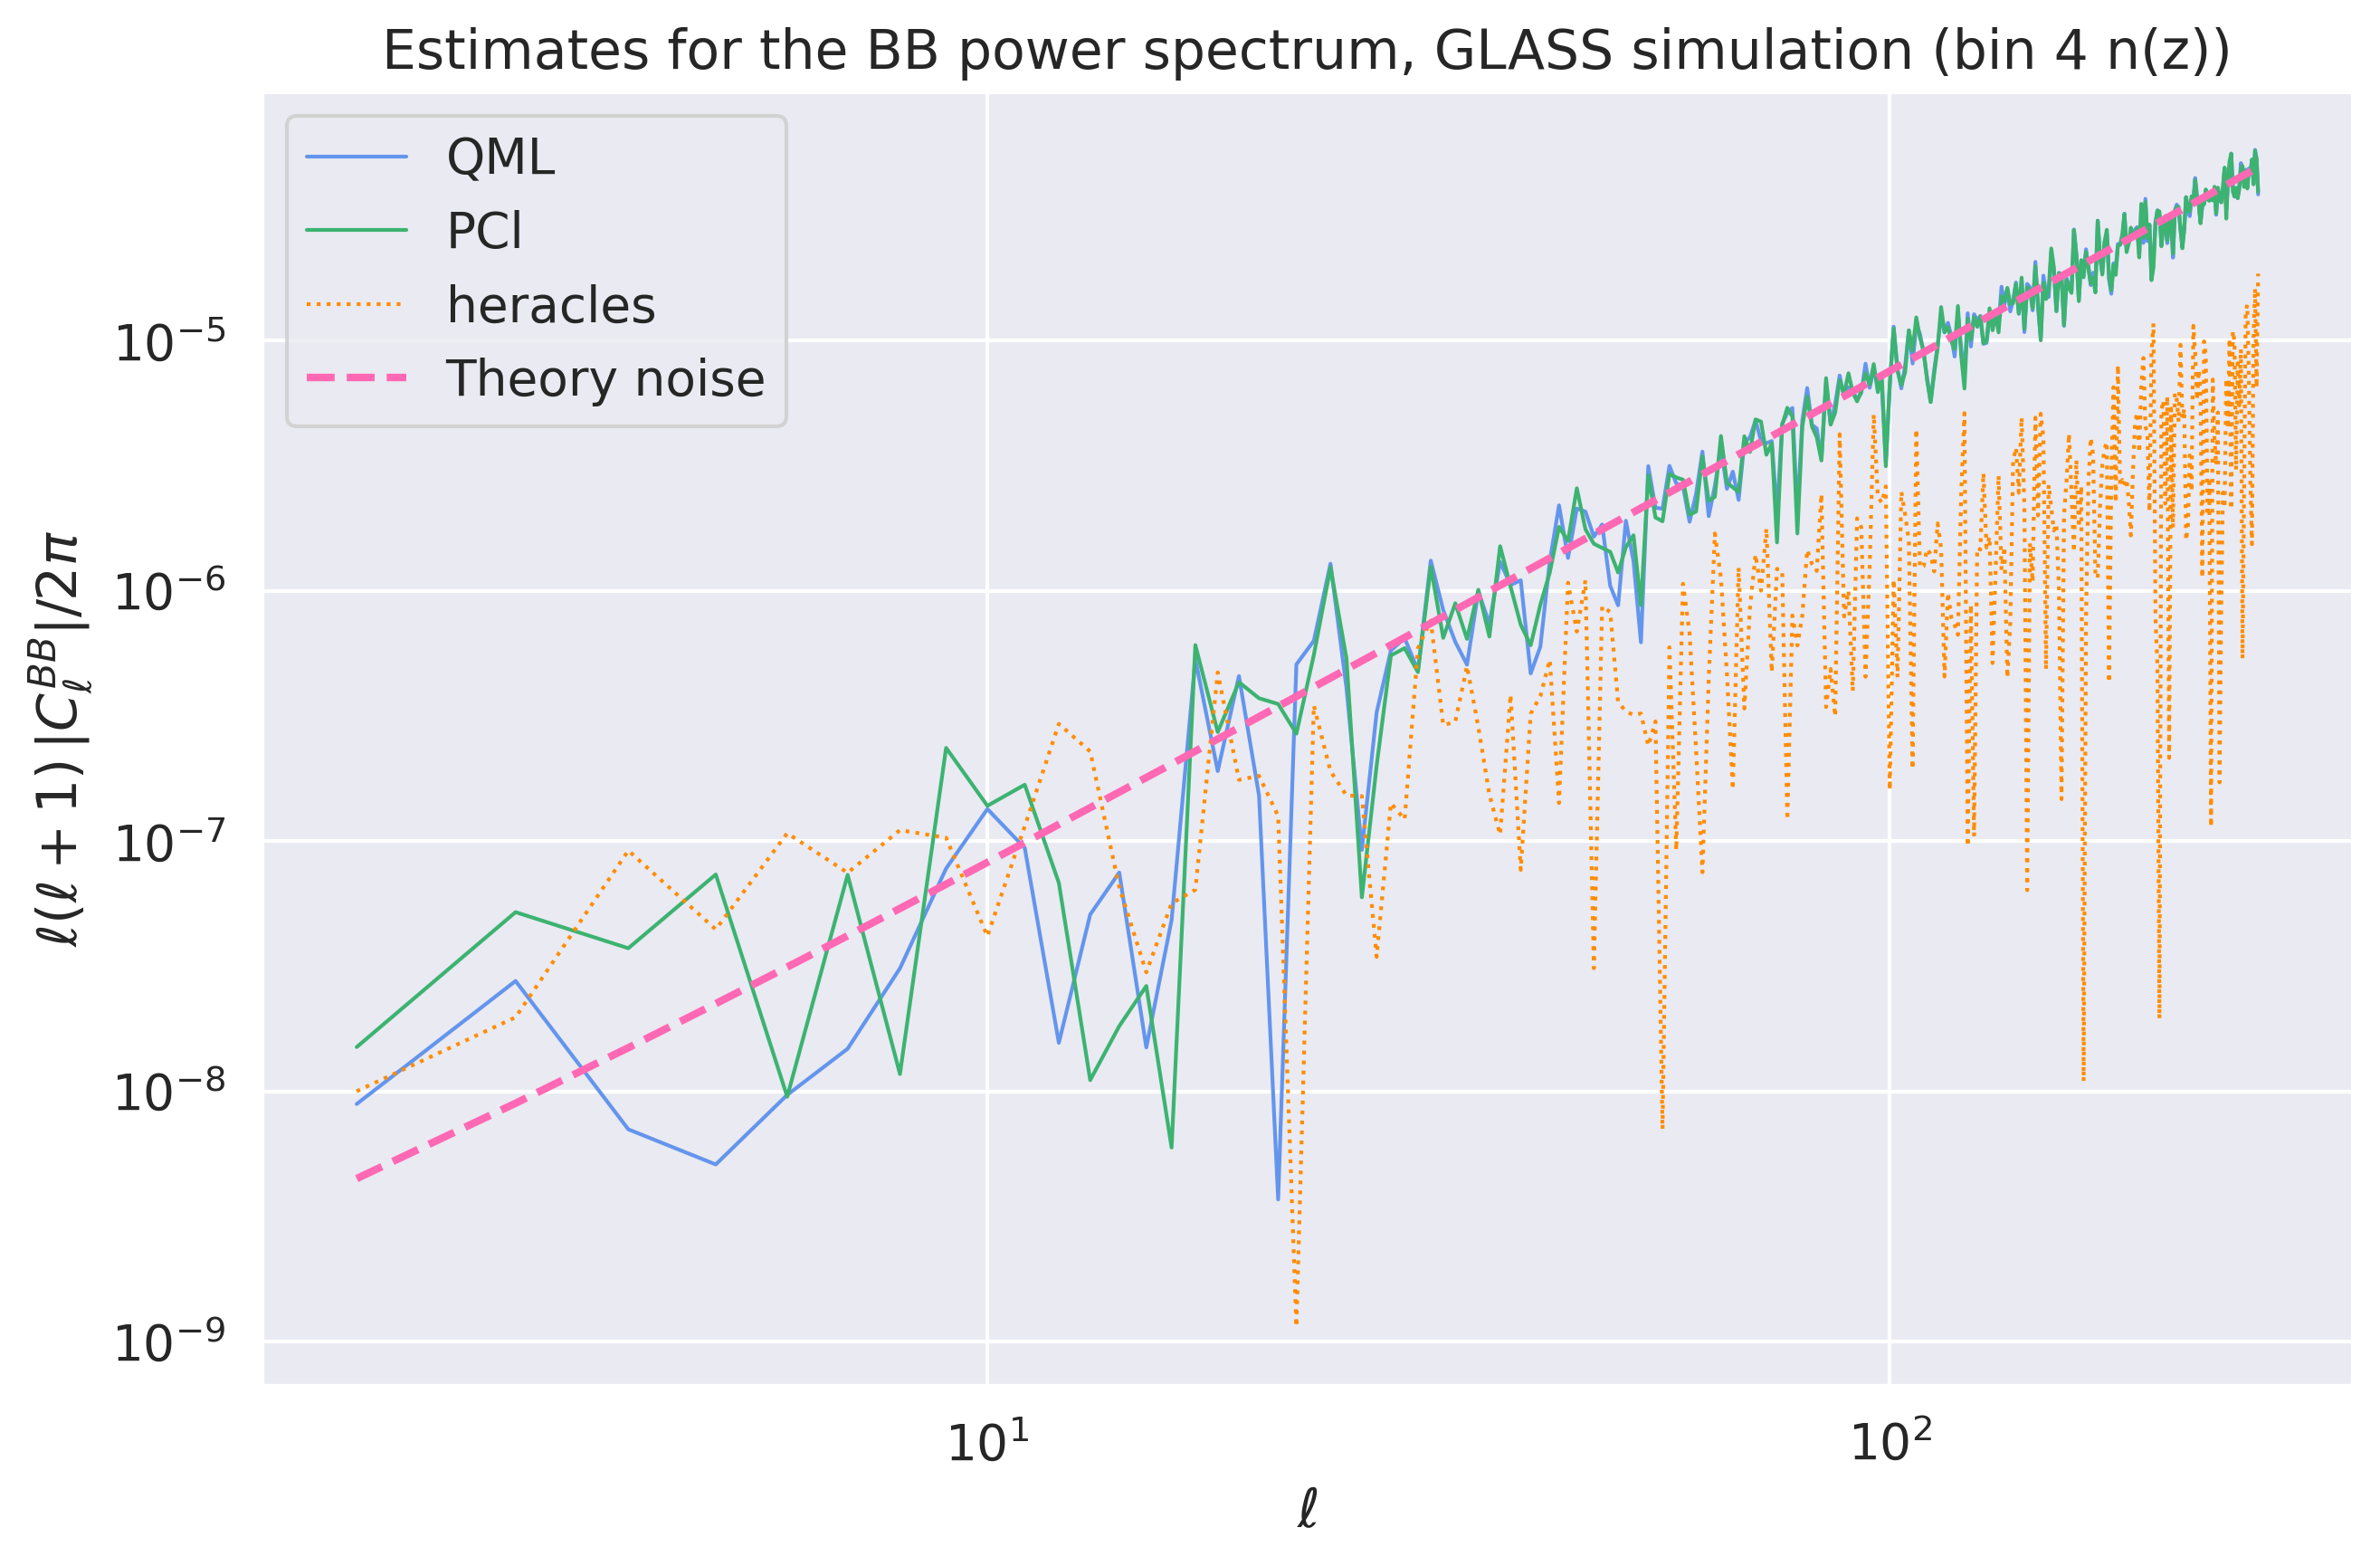

In [ ]:
fix, ax = plt.subplots(figsize=(9, 6))

ax.loglog(ells, ells * (ells + 1) * np.abs(cl_BB_QML) / (2 * np.pi), lw=1, c='cornflowerblue', label='QML')
ax.loglog(ells, ells * (ells + 1) * np.abs(cl_BB_PCl) / (2 * np.pi), lw=1, c='mediumseagreen', label='PCl')
ax.loglog(ells, ells * (ells + 1) * np.abs(cl_BB_heracles) / (2 * np.pi), lw=1, ls=':', c='darkorange', label='heracles')

ax.loglog(ells, ells * (ells + 1) * cl_noise / (2 * np.pi), lw=2, ls='--', c='hotpink', label='Theory noise')

ax.set_title('Estimates for the BB power spectrum, GLASS simulation (custom n(z))')
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$\ell (\ell + 1) \, |C_{\ell}^{BB}| / 2 \pi$')

ax.legend()

plt.tight_layout()
plt.show()
